In [1]:
#use extinction environment

import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm
import lmfit
import glob
import re
import pickle

from astropy.table import Table, Column, MaskedColumn, join, vstack
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import  join_skycoord
from astropy import table
from astropy.io import fits

import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Suppress SettingWithCopyWarnings
pd.options.mode.chained_assignment = None  # default='warn'

#for multiprocessing
from joblib import Parallel, delayed
import time

#to include extinction
from __future__ import print_function
from dustmaps.edenhofer2023 import Edenhofer2023Query
import extinction

import sys
import os

#import the pyphot module manually
sys.path.append('../Software/pyphot')
import pyphot
sys.path.append('../Software')
from corv_nicole.models import make_montreal_da_model
from corv_nicole.utils import build_montreal_da


We could not find the pickled WD models
Please enter a new path to the Koester models.
We could not find the pickled WD models. If you need to use these models, please re-import corv with the proper path.


# This notebook measures the DA WD Photometric Radii and Teffs using SDSS u+r+z Photometry (and Gaia BP+RP photometry if SDSS is unavailable) and Montreal Models

# Import the datasets

In [2]:
#read in the full tables, either from the backup file or from the latest version of the table
backup=False
if backup==True:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df_nb04.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df_nb04.csv')
else:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df.csv')

# The photometric fits depend only on the object, not the all the independent spectra
So reduce the data sets to only have one entry per object and then match to the full data set at the end

Keep only the relevant columns

Combine the SDSSV and eSDSS tables since photometric info is the same across these data sets

In [3]:
SDSSV_tab_short=SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id')[['gaia_dr3_source_id','l','b','r_med_geo',
                                                                  'r_lo_geo','r_hi_geo','phot_g_mean_flux',
                                                                  'phot_g_mean_flux_error','phot_g_mean_mag',
                                                                  'phot_bp_mean_flux','phot_bp_mean_flux_error',
                                                                  'phot_bp_mean_mag','phot_rp_mean_flux',
                                                                  'phot_rp_mean_flux_error','phot_rp_mean_mag',
                                                                  'phot_bp_rp_excess_factor','no_distance',
                                                                  'no_gaia_phot','clean','prob_psf','psf_mag_u',
                                                                  'psf_mag_g','psf_mag_r','psf_mag_i','psf_mag_z',
                                                                  'psf_magerr_u','psf_magerr_g','psf_magerr_r',
                                                                  'psf_magerr_i','psf_magerr_z','psf_flux_u',
                                                                  'psf_flux_g','psf_flux_r','psf_flux_i',
                                                                  'psf_flux_z','psf_fluxivar_u','psf_fluxivar_g',
                                                                  'psf_fluxivar_r','psf_fluxivar_i','psf_fluxivar_z',
                                                                  'mag_ab_u','magerr_ab_u','mag_ab_g','magerr_ab_g',
                                                                  'mag_ab_r','magerr_ab_r','mag_ab_i','magerr_ab_i',
                                                                  'mag_ab_z','magerr_ab_z','no_sdss_phot']]

eSDSS_tab_short=eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id')[['gaia_dr3_source_id','l','b','r_med_geo',
                                                                  'r_lo_geo','r_hi_geo','phot_g_mean_flux',
                                                                  'phot_g_mean_flux_error','phot_g_mean_mag',
                                                                  'phot_bp_mean_flux','phot_bp_mean_flux_error',
                                                                  'phot_bp_mean_mag','phot_rp_mean_flux',
                                                                  'phot_rp_mean_flux_error','phot_rp_mean_mag',
                                                                  'phot_bp_rp_excess_factor','no_distance',
                                                                  'no_gaia_phot','clean','prob_psf','psf_mag_u',
                                                                  'psf_mag_g','psf_mag_r','psf_mag_i','psf_mag_z',
                                                                  'psf_magerr_u','psf_magerr_g','psf_magerr_r',
                                                                  'psf_magerr_i','psf_magerr_z','psf_flux_u',
                                                                  'psf_flux_g','psf_flux_r','psf_flux_i',
                                                                  'psf_flux_z','psf_fluxivar_u','psf_fluxivar_g',
                                                                  'psf_fluxivar_r','psf_fluxivar_i','psf_fluxivar_z',
                                                                  'mag_ab_u','magerr_ab_u','mag_ab_g','magerr_ab_g',
                                                                  'mag_ab_r','magerr_ab_r','mag_ab_i','magerr_ab_i',
                                                                  'mag_ab_z','magerr_ab_z','no_sdss_phot']]
                                                                

In [4]:
tab_unique=pd.merge(left=SDSSV_tab_short,right=eSDSS_tab_short,on=['gaia_dr3_source_id','l','b','r_med_geo',
                                                        'r_lo_geo','r_hi_geo','phot_g_mean_flux',
                                                        'phot_g_mean_flux_error','phot_g_mean_mag',
                                                        'phot_bp_mean_flux','phot_bp_mean_flux_error',
                                                        'phot_bp_mean_mag','phot_rp_mean_flux',
                                                        'phot_rp_mean_flux_error','phot_rp_mean_mag',
                                                        'phot_bp_rp_excess_factor','no_distance',
                                                        'no_gaia_phot','clean','prob_psf','psf_mag_u',
                                                        'psf_mag_g','psf_mag_r','psf_mag_i','psf_mag_z',
                                                        'psf_magerr_u','psf_magerr_g','psf_magerr_r',
                                                        'psf_magerr_i','psf_magerr_z','psf_flux_u',
                                                        'psf_flux_g','psf_flux_r','psf_flux_i',
                                                        'psf_flux_z','psf_fluxivar_u','psf_fluxivar_g',
                                                        'psf_fluxivar_r','psf_fluxivar_i','psf_fluxivar_z',
                                                        'mag_ab_u','magerr_ab_u','mag_ab_g','magerr_ab_g',
                                                        'mag_ab_r','magerr_ab_r','mag_ab_i','magerr_ab_i',
                                                        'mag_ab_z','magerr_ab_z','no_sdss_phot'],how="outer")


In [5]:
#there are still duplicated gaia_dr3_source_ids
dup_id=tab_unique[tab_unique.duplicated(subset=['gaia_dr3_source_id'])]['gaia_dr3_source_id'].to_list()[1]
display(tab_unique.query('gaia_dr3_source_id==@dup_id'))
#these come from small differences in the (l,b) coordinates and the distances from accessing different releases
#of Gaia DR3 data
#the differences are negligible so drop duplicates just keeping the first entry
tab_unique=tab_unique.drop_duplicates(subset=['gaia_dr3_source_id'])
#reset the indices
indices=np.arange(0,len(tab_unique))
tab_unique.set_index(indices,inplace=True)

,gaia_dr3_source_id,l,b,r_med_geo,r_lo_geo,r_hi_geo,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,no_distance,no_gaia_phot,clean,prob_psf,psf_mag_u,psf_mag_g,psf_mag_r,psf_mag_i,psf_mag_z,psf_magerr_u,psf_magerr_g,psf_magerr_r,psf_magerr_i,psf_magerr_z,psf_flux_u,psf_flux_g,psf_flux_r,psf_flux_i,psf_flux_z,psf_fluxivar_u,psf_fluxivar_g,psf_fluxivar_r,psf_fluxivar_i,psf_fluxivar_z,mag_ab_u,magerr_ab_u,mag_ab_g,magerr_ab_g,mag_ab_r,magerr_ab_r,mag_ab_i,magerr_ab_i,mag_ab_z,magerr_ab_z,no_sdss_phot
1,152935195517952,176.967087,-47.621120,224.510941,217.157318,233.218216,1210.331441,1.996146,17.980106,861.746099,12.415707,18.000093,500.73813,7.525724,17.998869,1.125712,False,False,1.0,1.0,18.25882,17.89786,18.1197,18.32028,18.59645,0.019763,0.023338,0.022351,0.017949,0.030247,49.71304,69.3194,56.50901,46.97659,36.41161,1.221228,0.450421,0.738922,1.658054,0.970255,18.218824,0.022149,17.897863,0.02539,18.119706,0.024486,18.335296,0.020546,18.6269,0.031857,False
8546,152935195517952,176.967085,-47.621127,224.510940,217.157320,233.218220,1210.331441,1.996146,17.980106,861.746099,12.415707,18.000093,500.73813,7.525724,17.998869,1.125712,False,False,1.0,1.0,18.25882,17.89786,18.1197,18.32028,18.59645,0.019763,0.023338,0.022351,0.017949,0.030247,49.71304,69.3194,56.50901,46.97659,36.41161,1.221228,0.450421,0.738922,1.658054,0.970255,18.218824,0.022149,17.897863,0.02539,18.119706,0.024486,18.335296,0.020546,18.6269,0.031857,False


In [6]:
#break into smaller sets
try:
    os.makedirs('csv/unique_phot_short_sets')
except:
    pass

#make list of all unique object ids
obj_ids=tab_unique['gaia_dr3_source_id'].unique()
np.savetxt('csv/unique_phot_short_sets/obj_ids.txt', obj_ids.astype(str), fmt="%s")

#break up object ids into sets of 500
#save each set of ids
set_size=400
num_id_sets=int(len(obj_ids)/set_size)+1
print(num_id_sets)
np.savetxt('csv/unique_phot_short_sets/num_id_sets.txt', np.array([num_id_sets]), fmt="%s")
id_dict={}
for i in tqdm(range(num_id_sets)):
    id_dict['set_'+str(i)]=obj_ids[set_size*i:set_size*i+set_size]
    #save list
    np.savetxt('csv/unique_phot_short_sets/obj_ids_'+str(i)+'.txt', id_dict['set_'+str(i)].astype(str), fmt="%s")
    
#make a .csv for each set of ids
for i in range(num_id_sets):
    obj_ids=id_dict['set_'+str(i)]
    #search dataframe for objects in obj_id list
    short_set=tab_unique[tab_unique['gaia_dr3_source_id'].isin(obj_ids)]
    #save
    short_set.to_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv',index=False)
    

66


100%|█████████████████████████████████████████| 66/66 [00:00<00:00, 1469.47it/s]


In [7]:
#read in all data tables
num_id_sets=np.genfromtxt('csv/unique_phot_short_sets/num_id_sets.txt',dtype=int)
dict_unique={}
for i in tqdm(range(num_id_sets)):
    dict_unique['set_'+str(i)]=pd.read_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv')

100%|██████████████████████████████████████████| 66/66 [00:00<00:00, 518.13it/s]


# Correct the SDSS and Gaia photometry for extinction using Edenhofer 2023 dustmap and Fitzpatrick 1999 extinction curve
### Correct using the lo, med, and hi distances to account for distance uncertainty

Green 2018
- https://joss.theoj.org/papers/10.21105/joss.00695
- Paper for the dustmaps python package

Dustmaps Package Website
- https://dustmaps.readthedocs.io/en/latest/examples.html
- The Bayestar2019 map is 3D, meaning it takes the full location of the object into account. This map is also probabalistic, meaning that it stores random samples of how dust reddening could increase along each sightline.
- Use mode='mean' or mode='median' to get the mean/median reddening
- Bayestar19 reports reddening in an arbitrary unit that can be converted to extinction in different bands using the coefficients given in Table 1 of Green, Schlafly, Finkbeiner et al. (2019).

Edenhofer et al. (2023)
- https://ui.adsabs.harvard.edu/abs/2023arXiv230801295E/abstract
- A three-dimensional map of Milky Way dust extinction, with a Gaussian process prior on the logarithm of the dust extinction density. The prior is implemented on a spherical grid. The map starts at 69 pc and extends out to 1.25 kpc in distance from the Sun. It has an angular resolution of 14’ and a maximum distance voxalization of 0.4 pc at 69 pc and a minimum distance voxalization of 7 pc at 1250 pc. The map is based on the stellar distance and extinction estimates of Zhang, Green & Rix (2023), and therefore reports extinctions in their units.
- We believe our dust reconstruction to be an underestimation of the true extinction toward dense dust clouds.
- For extremely low extinctions the assumption of A being Gaussian is poor due to the positivity prior in the ZGR23 catalog. We correct for this bias towards higher estimated extinction in regions with assumed extremely low true extinctions post-hoc by cutting away the innermost 69 pc as described in Section 5 and publish an auxiliary map of integrated extinction out to 69 pc from the sun to correct integrated LOS predictions for the removed extinction.
- Extinction is given in unitless E from Zhang 2023
- Zhang 2023 extinction curve https://zenodo.org/records/7811871
- From Edenhofer 2023 paper, they multiply E by 2.8 to get Av (see wavelength=540 nm on above extinction curve)
- all NaNs result from the object not being in the 69pc-1250pc validity range for this map. If the object is closer than 69 pc just set extinction to 0. If the object is further than 1250pc, set d=1250pc and get minimum extinction.

Fitzpatrick 1999
- https://iopscience.iop.org/article/10.1086/316293
- Paper used for the extinction curves
- $A_V$ is the extinction in the V band
- These are often characterized using the parameter $R=A(V)/E(B-V)$, i.e., the ratio of total to selective extinction at V. The value of R ranges between about 2.2 and 5.8 for sight lines along which UV extinction has also been measured, with a mean value of ~3.1 for the diffuse interstellar medium.

Extinction Python Package
- https://extinction.readthedocs.io/en/latest/

Pyphot Python Package
- https://mfouesneau.github.io/pyphot/#installation

In [8]:
#download the data for the Edenhofer (2023) dustmap
"""
from dustmaps.config import config
config['data_dir'] = '~/Users/nicolecrumpler/anaconda3/envs/extinction/lib/python3.11/site-packages/dustmaps'

import dustmaps.edenhofer2023
dustmaps.edenhofer2023.fetch()
"""

"\nfrom dustmaps.config import config\nconfig['data_dir'] = '~/Users/nicolecrumpler/anaconda3/envs/extinction/lib/python3.11/site-packages/dustmaps'\n\nimport dustmaps.edenhofer2023\ndustmaps.edenhofer2023.fetch()\n"

In [9]:
def edenhofer_extinction_correction(wd_table):
    # Query Edenhofer2023Query to get mean E(B-V) in arbitrary units
    ehq = Edenhofer2023Query(integrated=True) #integrated=True gives integrated extinction from coordinate
    
    distance_sets=['lo','med','hi']
    
    u_exts=[]
    g_exts=[]
    r_exts=[]
    i_exts=[]
    z_exts=[]
    Gaia_g_exts=[]
    Gaia_bp_exts=[]
    Gaia_rp_exts=[]
    u_dereds=[]
    g_dereds=[]
    r_dereds=[]
    i_dereds=[]
    z_dereds=[]
    Gaia_g_dereds=[]
    Gaia_bp_dereds=[]
    Gaia_rp_dereds=[]
    
    for distance_set in distance_sets:     
        # Turn galactic coordinates into a SkyCoord object
        #map only goes out to 1250pc, so if distance greater than this set to 1244 to get minimum on reddening
        distance_list=[]
        for i in range(len(wd_table)):
            dist=wd_table['r_'+distance_set+'_geo'].to_list()[i]
            if dist<1250:
                distance_list.append(dist)
            else:
                distance_list.append(1244)
        coords = SkyCoord(frame="galactic", l=wd_table['l'].to_list()*u.deg, b=wd_table['b'].to_list()*u.deg, distance = distance_list* u.pc)

        #get extinction at coordinates
        ehq_mean = ehq.query(coords, mode='mean')

        # Convert E to Av
        wd_table['av_'+distance_set]=2.8*ehq_mean
        #all NaNs from objects too near (<69pc) or too far (>1.25 kpc)
        #below 69 pc, just set extinction to 0 since very near
        wd_table['av_'+distance_set]=wd_table['av_'+distance_set].fillna(0)

        # Use pyphot to get the SDSS and Gaia photometric band wavelengths
        lib = pyphot.get_library()
        sdss_filters = [lib['SDSS_u'],lib['SDSS_g'],lib['SDSS_r'],lib['SDSS_i'],lib['SDSS_z']]
        sdss_phot_wavl = np.array([x.lpivot.to('angstrom').value for x in sdss_filters])
        gaia_filters = [lib['Gaia_G'],lib['Gaia_BP'], lib['Gaia_RP']]
        gaia_phot_wavl = np.array([x.lpivot.to('angstrom').value for x in gaia_filters])

        # A(V)=R*E(B-V) where the mean value of R for the diffuse interstellar medium is 3.1
        Rv = 3.1

        # For each point, find extinction using the Fitzpatrick (1999) dust extinction function from the extinction package
        ext_all_sdss=[]
        ext_all_gaia=[]
        for i in range(len(wd_table)):
            av=wd_table['av_'+distance_set][i]
            #returns extinction in magnitudes at each SDSS and Gaia photometric band wavelength
            ext_all_sdss.append(extinction.fitzpatrick99(sdss_phot_wavl, av, Rv))
            ext_all_gaia.append(extinction.fitzpatrick99(gaia_phot_wavl, av, Rv))
        ext_all_sdss = np.array(ext_all_sdss)
        ext_all_gaia = np.array(ext_all_gaia)

        # Save the extinction in each band
        u_ext = ext_all_sdss.T[0]
        g_ext = ext_all_sdss.T[1]
        r_ext = ext_all_sdss.T[2]
        i_ext = ext_all_sdss.T[3]
        z_ext = ext_all_sdss.T[4]
        Gaia_g_ext = ext_all_gaia.T[0]
        Gaia_bp_ext = ext_all_gaia.T[1]
        Gaia_rp_ext = ext_all_gaia.T[2]

        # Subtract out the extinction to find de-reddened magnitude on AB/Vega scale
        u_dered = wd_table['mag_ab_u'] - u_ext
        g_dered = wd_table['mag_ab_g'] - g_ext
        r_dered = wd_table['mag_ab_r'] - r_ext
        i_dered = wd_table['mag_ab_i'] - i_ext
        z_dered = wd_table['mag_ab_z'] - z_ext
        Gaia_g_dered = wd_table['phot_g_mean_mag'] - Gaia_g_ext
        Gaia_bp_dered = wd_table['phot_bp_mean_mag'] - Gaia_bp_ext
        Gaia_rp_dered = wd_table['phot_rp_mean_mag'] - Gaia_rp_ext
        
        u_exts.append(u_ext)
        g_exts.append(g_ext)
        r_exts.append(r_ext)
        i_exts.append(i_ext)
        z_exts.append(z_ext)
        Gaia_g_exts.append(Gaia_g_ext)
        Gaia_bp_exts.append(Gaia_bp_ext)
        Gaia_rp_exts.append(Gaia_rp_ext)
        u_dereds.append(u_dered)
        g_dereds.append(g_dered)
        r_dereds.append(r_dered)
        i_dereds.append(i_dered)
        z_dereds.append(z_dered)
        Gaia_g_dereds.append(Gaia_g_dered)
        Gaia_bp_dereds.append(Gaia_bp_dered)
        Gaia_rp_dereds.append(Gaia_rp_dered)

    return(u_exts,g_exts,r_exts,i_exts,z_exts,Gaia_g_exts,Gaia_bp_exts,Gaia_rp_exts,u_dereds,g_dereds,r_dereds,i_dereds,
           z_dereds,Gaia_g_dereds,Gaia_bp_dereds,Gaia_rp_dereds)


### Add the extinction corrections to all stars

In [10]:
def parallelprocess_extinction(i):
    
    print(i)
    
    u_exts,g_exts,r_exts,i_exts,z_exts,Gaia_g_exts,Gaia_bp_exts,Gaia_rp_exts,u_dereds,g_dereds,r_dereds,i_dereds,z_dereds,Gaia_g_dereds,Gaia_bp_dereds,Gaia_rp_dereds=edenhofer_extinction_correction(dict_unique['set_'+str(i)])
        
    distance_sets=['lo','med','hi']
    
    for j in range(len(distance_sets)):
        distance_set=distance_sets[j]
        u_ext=u_exts[j]
        g_ext=g_exts[j]
        r_ext=r_exts[j]
        i_ext=i_exts[j]
        z_ext=z_exts[j]
        Gaia_g_ext=Gaia_g_exts[j]
        Gaia_bp_ext=Gaia_bp_exts[j]
        Gaia_rp_ext=Gaia_rp_exts[j]
        u_dered=u_dereds[j]
        g_dered=g_dereds[j]
        r_dered=r_dereds[j]
        i_dered=i_dereds[j]
        z_dered=z_dereds[j]
        Gaia_g_dered=Gaia_g_dereds[j]
        Gaia_bp_dered=Gaia_bp_dereds[j]
        Gaia_rp_dered=Gaia_rp_dereds[j]
        
        # Save the extinction and de-reddened magnitude in each band
        dict_unique['set_'+str(i)]['u_ext_'+distance_set] = u_ext
        dict_unique['set_'+str(i)]['g_ext_'+distance_set] = g_ext
        dict_unique['set_'+str(i)]['r_ext_'+distance_set] = r_ext
        dict_unique['set_'+str(i)]['i_ext_'+distance_set] = i_ext
        dict_unique['set_'+str(i)]['z_ext_'+distance_set] = z_ext
        dict_unique['set_'+str(i)]['gaia_g_ext_'+distance_set] = Gaia_g_ext
        dict_unique['set_'+str(i)]['gaia_bp_ext_'+distance_set] = Gaia_bp_ext
        dict_unique['set_'+str(i)]['gaia_rp_ext_'+distance_set] = Gaia_rp_ext
        dict_unique['set_'+str(i)]['u_dered_'+distance_set] = u_dered
        dict_unique['set_'+str(i)]['g_dered_'+distance_set] = g_dered
        dict_unique['set_'+str(i)]['r_dered_'+distance_set] = r_dered
        dict_unique['set_'+str(i)]['i_dered_'+distance_set] = i_dered
        dict_unique['set_'+str(i)]['z_dered_'+distance_set] = z_dered
        dict_unique['set_'+str(i)]['gaia_g_dered_'+distance_set] = Gaia_g_dered
        dict_unique['set_'+str(i)]['gaia_bp_dered_'+distance_set] = Gaia_bp_dered
        dict_unique['set_'+str(i)]['gaia_rp_dered_'+distance_set] = Gaia_rp_dered
        
    #save as a .csv
    dict_unique['set_'+str(i)].to_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv',index=False)


In [ ]:
#run for each set of ids
print(num_id_sets)
#set n_jobs=-3 to spawn n-2 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-3, verbose=11)(delayed(parallelprocess_extinction)(i) for i in range(num_id_sets))


### Read back in the short tables
The above method saves the .csv but doesn't overwrite the dataframe, so you have to read back in the results

In [12]:
#read in all data tables
dict_unique={}
for i in tqdm(range(num_id_sets)):
    dict_unique['set_'+str(i)]=pd.read_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv')

100%|██████████████████████████████████████████| 66/66 [00:00<00:00, 130.36it/s]


# Define functions to fit the Photometry with Warwick Templates and Pyphot

Fit with both SDSS and Gaia photometry if available

Fit for lo, med, and high distance photometry

In [13]:
#physical constants in CGS units
c = 2.998e10 #cm/s
k = 1.38e-16 #erg/K
h = 6.626e-27 #erg s

#Balmer series line centroids, for vacuum wavelengths
halpha = 6564.61 #ang
hbeta = 4862.68 #ang
hgamma = 4341.68 #ang
hdelta = 4102.89 #ang

#physical constants in SI units
speed_light = 299792458 #m/s
radius_sun = 6.957e8 #m
mass_sun = 1.9884e30 #kg
newton_G = 6.674e-11 #N m^2/kg^2
pc_to_m = 3.086775e16

In [14]:
#get the Warwick DA model

modpath_m='models/montreal_da'
base_wavl, montreal_model, montreal_model_low_logg, table = build_montreal_da(modpath_m,flux_unit = 'flam')


### Converting AB/Vega magnitudes to fluxes
Let $G=$G passband magnitude, $g$=G passband flux, and $G_0$ be the zero-point of the magnitude system.

To convert from flux to magnitudes (pyphot zero points are positive, so subtract this off):
$$G=-2.5\text{log}_{10}(g)-G_0$$ 
The error propagation for this is
$$\delta G=\sqrt{\left(\frac{\partial G}{\partial g}\right)^2\delta g^2+\delta G_0^2}=\sqrt{\left(\frac{-2.5}{g\text{ ln}(10)}\right)^2\delta g^2+\delta G_0^2}$$
Uncertainties in Gaia photometry are only given in flux units and must be propagated from flux to magnitude via standard error propagation (although in magnitude space the errors are no longer symmetric). Must add in quadrature the zero point uncertainty from Table 3 in Riello 2021 (https://ui.adsabs.harvard.edu/abs/2021A%26A...649A...3R/abstract ).

To convert from magnitudes to flux:
$$g=10^{-0.4(G+G_0)}$$
The error propagation for this is
$$\delta G=|\left(\frac{\partial g}{\partial G}\right)\delta G|=-0.4\times\text{ln}(10)\times10^{-0.4(G+G_0)}\delta G$$ if we assume the error on the zero point is negligible. It is better to work in flux space since the errors are symmetric

Note also that SDSS magnitudes have been corrected to the AB system and Gaia magnitudes are on the Vega system.

### Link to the montreal/warwick model data:
- https://warwick.ac.uk/fac/sci/physics/research/astro/people/tremblay/modelgrids/
- We use ⟨3D⟩ pure-hydrogen (DA) NLTE spectra
- The flux at Earth is f = $4*\pi*R^2/D^2 *$ Eddington flux

In [15]:
def mag_to_flux_spec_Vega(mag, filt, e_mag = None):
    #convert from magntiudes on the Vega system to flux for a particular filter
    #Gaia magnitudes are on the Vega system
    if e_mag is not None:
        #compute the flux error given the error on the magnitude
        #assume the error on the zero point is negligible
        return (10**(-0.4*(mag + filt.Vega_zero_mag)), np.abs((np.log(10)*(-0.4)*10**(-0.4 * (mag + filt.Vega_zero_mag)) * e_mag)))
    else:
        return 10**(-0.4*(mag + filt.Vega_zero_mag))
    
def mag_to_flux_spec_AB(mag, filt, e_mag = None):
    #convert from magntiudes on the AB system to flux for a particular filter
    #SDSS magnitudes are on the AB system
    if e_mag is not None:
        #compute the flux error given the error on the magnitude
        #assume the error on the zero point is negligible
        return (10**(-0.4*(mag + filt.AB_zero_mag)), np.abs((np.log(10)*(-0.4)*10**(-0.4 * (mag + filt.AB_zero_mag)) * e_mag)))
    else:
        return 10**(-0.4*(mag + filt.AB_zero_mag))
    
def template(teff, logg, radius, distance):
    #get montreal model flux spectrum for a WD with a given radius, located a given distance away
    
    fl= 4*np.pi*montreal_model((teff,logg))#flux in physical units
    
    #convert to SI units
    radius = radius * radius_sun # Rsun to meter
    distance = distance * pc_to_m # Parsec to meter
    
    fl = (radius / distance)**2 * fl
    return fl
    

def get_model_flux_sdss(params):
    #get model photometric flux for a WD with a given radius, located a given distance away
    teff, logg, radius, distance = params['teff'], params['logg'], params['radius'], params['distance']
    
    fl = template(teff, logg, radius, distance) 
            
    flux = np.array([sdss_filters[i].get_flux(base_wavl * pyphot.unit['angstrom'], fl * pyphot.unit['erg/s/cm**2/angstrom'], axis = 1).to('erg/s/cm**2/angstrom').value for i in range(len(sdss_filters))])
    return flux

def get_model_flux_gaia(params):
    #get model photometric flux for a WD with a given radius, located a given distance away
    teff, logg, radius, distance = params['teff'], params['logg'], params['radius'], params['distance']
    
    fl = template(teff, logg, radius, distance) 
            
    flux = np.array([gaia_filters[i].get_flux(base_wavl * pyphot.unit['angstrom'], fl * pyphot.unit['erg/s/cm**2/angstrom'], axis = 1).to('erg/s/cm**2/angstrom').value for i in range(len(gaia_filters))])
    return flux
    

def residual_sdss(params, obs_flux = None, e_obs_flux = None):
    #calculate the chi2 between the model and the fit
    model_flux = get_model_flux_sdss(params)
    
    chisquare = ((model_flux - obs_flux) / e_obs_flux)**2

    return chisquare

def residual_gaia(params, obs_flux = None, e_obs_flux = None):
    #calculate the chi2 between the model and the fit
    model_flux = get_model_flux_gaia(params)

    chisquare = ((model_flux - obs_flux) / e_obs_flux)**2

    return chisquare

def get_parameters_sdss(obs_flux, e_obs_flux, vary_logg=False, p0 = [10000, 8, 0.003, 100]):          
    #use lmfit.minimize to fit the model to the data
    params = lmfit.Parameters()
    params.add('teff', value = p0[0], min = 1501, max = 129999, vary = True)
    params.add('logg', value = p0[1], min=7, max=9, vary=vary_logg)
    params.add('radius', value = p0[2], min = 0.000001, max = 0.05, vary = True)
    params.add('distance', value = p0[3], min = 1, max = 20000, vary = False)
            
    result = lmfit.minimize(residual_sdss, params, kws = dict(obs_flux = obs_flux, e_obs_flux = e_obs_flux), method = 'leastsq')
        
    return result

def get_parameters_gaia(obs_flux, e_obs_flux, vary_logg=False, p0 = [10000, 8, 0.003, 100]):          
    #use lmfit.minimize to fit the model to the data
    params = lmfit.Parameters()
    params.add('teff', value = p0[0], min = 1501, max = 129999, vary = True)
    params.add('logg', value = p0[1], min=7, max=9, vary=vary_logg)
    params.add('radius', value = p0[2], min = 0.000001, max = 0.05, vary = True)
    params.add('distance', value = p0[3], min = 1, max = 20000, vary = False)
            
    result = lmfit.minimize(residual_gaia, params, kws = dict(obs_flux = obs_flux, e_obs_flux = e_obs_flux), method = 'leastsq')
        
    return result

### Fit the SDSS u+r+z filters
From our analysis, this is as accurate as fitting all 5 filters and is faster

### Also fit the Gaia BP+RP filters, but prioritize SDSS photometry
From our analysis, Gaia G is fully covered by the BP/RP filters so adding in this extra filter doesn't contribute much information and makes the fit significantly slower

High values of the phot_bp_rp_excess_factor can indicate issues with the Gaia BP/RP photometry
https://gea.esac.esa.int/archive/documentation/GDR2/Data_processing/chap_cu5pho/sec_cu5pho_qa/ssec_cu5pho_excessflux.html
Consider Gaia photometry to be clean so long as this <2

Gaia fluxes are given in electrons/second. We can convert the flux in each band to erg/s/cm^2/AA using the magnitude-> flux conversion. For the errors on the flux, use Table 5.3 from https://gea.esac.esa.int/archive/documentation/GEDR3/Data_processing/chap_cu5pho/cu5pho_sec_photProc/cu5pho_ssec_photCal.html.

To convert Gaia fluxes to mean energy in W/m^2/nm, multipley by the coefficient $c_\lambda$ where
$$c_\lambda=1.346109E-21\text{, }3.009167E-21\text{, }1.638483E-21$$
for the Gaia g, bp, and rp bands respectively. Then, to convert W/m^2/nm to erg/s/cm^2/AA, multiply by 100.

### From our test on fixing logg
- Fixing logg has important consequences for the measured temperature at low temperatures (~20%). The effects on the measured radius are sub-dominant to the effects of the distance uncertainty.
- Gaia G is redundant with Gaia BP/RP, so Gaia only offers 2 constraints on the 3 independent parameters of radius/logg/teff. This was causing the Gaia fit to regularly (>90% of the time) hit the logg grid boundary, since logg is less constrained by the photometric data than radius/teff. Gaia data is really only suitable for measuring radius/teff at fixed logg with this method.
- So, we leave logg free in the SDSS u+r+z fit and re-fit fixing logg=8 if the initial fit fails or hits the logg grid boundary. We provide a flag to indicate which fit was used. For Gaia data, we fix logg=8 in our fit. For science, we prioritize the results from SDSS photometry over those from Gaia photometry.

In [16]:
# Use pyphot to get the SDSS and Gaia photometric band wavelengths we want to fit
lib = pyphot.get_library()
sdss_filters = [lib['SDSS_u'],lib['SDSS_r'],lib['SDSS_z']]
sdss_phot_wavl = np.array([x.lpivot.to('angstrom').value for x in sdss_filters])
gaia_filters = [lib['Gaia_BP'], lib['Gaia_RP']]
gaia_phot_wavl = np.array([x.lpivot.to('angstrom').value for x in gaia_filters])

In [17]:
def fit_phot(wd_table,distance_set,plot=False,savefig=False):
    
    #For SDSS fit allowing logg to vary, if the fit fails or hits the edge of the grid
    #fit logg=7,8,9 and add difference in quadrature
    
    #for Gaia, fit logg=7,8,9 and add difference in quadrature
    #allowing logg to vary results in hitting the edge of the grid
    
    radius_array_sdss=[]
    e_radius_array_sdss=[]
    teff_array_sdss=[]
    e_teff_array_sdss=[]
    logg_array_sdss=[]
    e_logg_array_sdss=[]
    redchi_array_sdss=[]
    
    radius_array_gaia=[]
    e_radius_array_gaia=[]
    teff_array_gaia=[]
    e_teff_array_gaia=[]
    logg_array_gaia=[]
    e_logg_array_gaia=[]
    redchi_array_gaia=[]
    
    #add a flag to indicate whether SDSS or Gaia photometry was used (or if there's no good available photometry)
    #0=no phot, 1=SDSS, 2=Gaia
    photometry_source_flag=np.full(len(wd_table), 0)
    #add a flag to indicate whether logg was fixed
    #0=fit failed/no_phot for that survey, 1=logg free to vary, 2=logg fixed
    sdss_logg_flag=[]
    gaia_logg_flag=[]
    
    for i in tqdm(range(len(wd_table))):
        #fit objects with clean SDSS photometry
        if wd_table['no_sdss_phot'][i]==False and wd_table['clean'][i]==1:
            #convert extinction-corrected SDSS magnitude to flux in erg/s/cm^2/AA
            obs_flux_u, e_obs_flux_u = mag_to_flux_spec_AB(wd_table['u_dered_'+distance_set][i],sdss_filters[0],wd_table['magerr_ab_u'][i])
            obs_flux_r, e_obs_flux_r = mag_to_flux_spec_AB(wd_table['r_dered_'+distance_set][i],sdss_filters[1],wd_table['magerr_ab_r'][i])
            obs_flux_z, e_obs_flux_z = mag_to_flux_spec_AB(wd_table['z_dered_'+distance_set][i],sdss_filters[2],wd_table['magerr_ab_z'][i])
            obs_flux=np.array([obs_flux_u,obs_flux_r,obs_flux_z])
            e_obs_flux=np.array([e_obs_flux_u,e_obs_flux_r,e_obs_flux_z])
            
            #first fit for varying logg
            result = get_parameters_sdss(obs_flux,e_obs_flux,vary_logg=True,p0 = [10000, 8, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
            
            #check if the fit failed
            try:
                check_nan=[result.params['radius'].stderr,result.params['radius'].value,result.params['teff'].stderr,
                       result.params['teff'].value,result.params['logg'].stderr,result.params['logg'].value]
                fit_fail=np.isnan(check_nan).any()
                #also check if the logg fit hits the edge of the grid
                if np.abs(result.params['logg'].value-7)<0.001 or np.abs(result.params['logg'].value-9)<0.001:
                    fit_fail=True
                    
            except:
                fit_fail=True
                
            if fit_fail==True:
                #if that fails, fit for logg=7,8,9
                logg7 = get_parameters_sdss(obs_flux,e_obs_flux,p0 = [10000, 7, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
                logg8 = get_parameters_sdss(obs_flux,e_obs_flux,p0 = [10000, 8, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
                logg9 = get_parameters_sdss(obs_flux,e_obs_flux,p0 = [10000, 9, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
            
            #save the fit results
            if fit_fail==False:
                #radius in solar units
                radius=result.params['radius'].value
                radius_array_sdss.append(radius)
                #error on the radius is stderr in measured radius
                err=result.params['radius'].stderr
                e_radius_array_sdss.append(err)
                #photometric temperature in K
                teff=result.params['teff'].value
                teff_array_sdss.append(teff)
                #error on photometric temperature in K
                e_teff=result.params['teff'].stderr
                e_teff_array_sdss.append(e_teff)
                #photometric logg in dex
                logg=result.params['logg'].value
                logg_array_sdss.append(logg)
                #error on photometric logg in dex
                e_logg=result.params['logg'].stderr
                e_logg_array_sdss.append(e_logg)
                #reduced chi2
                redchi_val=result.redchi
                redchi_array_sdss.append(redchi_val)
            
            fit_fail_fixed=False
            
            if fit_fail==True:
                #radius in solar units
                try:
                    radius=logg8.params['radius'].value
                    radius_array_sdss.append(radius)
                except:
                    radius_array_sdss.append(np.nan)
                    fit_fail_fixed=True
                #error on the radius is stderr in measured radius and the absolute value of the difference in the logg=7,9 radius results added in quadrature
                try:
                    err=np.sqrt(logg8.params['radius'].stderr**2 + np.abs(logg7.params['radius'].value - logg9.params['radius'].value)**2 )
                    e_radius_array_sdss.append(err)
                except:
                    e_radius_array_sdss.append(np.nan)
                    fit_fail_fixed=True
                #photometric temperature in K
                try:
                    teff=logg8.params['teff'].value
                    teff_array_sdss.append(teff)
                except:
                    teff_array_sdss.append(np.nan)
                    fit_fail_fixed=True
                #error on photometric temperature in K
                try:
                    e_teff=np.sqrt(logg8.params['teff'].stderr**2 + np.abs(logg7.params['teff'].value - logg9.params['teff'].value)**2 )
                    e_teff_array_sdss.append(e_teff)
                except:
                    e_teff_array_sdss.append(np.nan)
                    fit_fail_fixed=True
                #photometric logg in dex
                logg=8
                logg_array_sdss.append(logg)
                #error on photometric logg in dex
                e_logg=np.nan
                e_logg_array_sdss.append(e_logg)
                #reduced chi2
                try:
                    redchi_val=logg8.redchi
                    redchi_array_sdss.append(redchi_val)
                except:
                    redchi_array_sdss.append(np.nan)
                    fit_fail_fixed=True
                    
            #add the flag information
            if fit_fail==False:
                flag=1
                plot_result=result
            elif fit_fail_fixed==False:
                flag=2
                plot_result=logg8
            else:
                flag=0
                plot_result=logg8
            sdss_logg_flag.append(flag)
            
        
            if plot==True:
                #get the SDSS filter information
                sdss_u_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/sdss_u.csv',skiprows=8)
                sdss_r_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/sdss_r.csv',skiprows=8)
                sdss_z_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/sdss_z.csv',skiprows=8)
                # plot the model spectrum, model photometric flux, observed photometric flux, and SDSS urz filter response curves
                # with the fit results
                plt.style.use('stefan.mplstyle')
                fig_sdss, ax1 =plt.subplots(1,1,figsize=(9,9))
                ax1.errorbar([sdss_filters[j].lpivot.to('angstrom').value for j in range(len(sdss_filters))], obs_flux, yerr = e_obs_flux, linestyle = 'none', marker = 'None', color = 'k', capsize = 5, label = 'Observed SED', zorder = 10)
                ax1.plot([sdss_filters[j].lpivot.to('angstrom').value for j in range(len(sdss_filters))], get_model_flux_sdss(plot_result.params), 'co', markersize = 10, label = 'Model SED')
                
                ax1.fill_between(x= sdss_u_info['WAVELENGTH'], y1= sdss_u_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2,label='Filter Response Curve')
                ax1.fill_between(x= sdss_r_info['WAVELENGTH'], y1= sdss_r_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2)
                ax1.fill_between(x= sdss_z_info['WAVELENGTH'], y1= sdss_z_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2)
                
                model_fl = template(plot_result.params['teff'].value, plot_result.params['logg'].value, plot_result.params['radius'].value, plot_result.params['distance'].value)
                mask = (3600 < base_wavl)*(base_wavl<9000)
                ax1.plot(base_wavl[mask], model_fl[mask], c = 'k', label = 'Model Spectrum')
                
                ax1.text(0.57, 0.70,  "$T_{eff}$" + " = {:2.6} $K$".format(plot_result.params['teff'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.65, "$\log g$" + " = {:2.5f}".format(plot_result.params['logg'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.60, r'$Radius = ${:2.5f} $R_\odot$'.format(plot_result.params['radius'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.55, '$Distance = ${:2.1f} $pc$'.format(plot_result.params['distance'].value), transform = plt.gca().transAxes, fontsize=18)
                ax1.text(0.57, 0.50, r'$\chi_r^2 = ${:2.2f}'.format(plot_result.redchi), transform = plt.gca().transAxes, fontsize = 18)
                
                ax1.set_xlim((3450, 9000))
                ax1.set_xlabel(r'Wavelength $(\AA)$')
                ax1.set_ylabel('Flux $(erg/s/cm^2/\AA)$')
                ax1.set_title('SDSS $u$+$r$+$z$ Photometric Fit')
                ax1.legend()
                plt.show()
        else:
            #no clean SDSS photometry available
            radius_array_sdss.append(np.nan)
            e_radius_array_sdss.append(np.nan)
            teff_array_sdss.append(np.nan)
            e_teff_array_sdss.append(np.nan)
            logg_array_sdss.append(np.nan)
            e_logg_array_sdss.append(np.nan)
            redchi_array_sdss.append(np.nan)
            sdss_logg_flag.append(0)
            fig_sdss=None
            
        #fit objects with clean Gaia photometry
        if wd_table['no_gaia_phot'][i]==False and wd_table['phot_bp_rp_excess_factor'][i]<2:
            
            #convert extinction-corrected Gaia magnitude to flux in erg/s/cm^2/AA
            obs_flux = np.array([mag_to_flux_spec_Vega(wd_table['gaia_bp_dered_'+distance_set][i], gaia_filters[0]),
                                 mag_to_flux_spec_Vega(wd_table['gaia_rp_dered_'+distance_set][i], gaia_filters[1])])
            #convert Gaia flux errors (electron/s) to erg/s/cm^2/AA
            e_obs_flux = np.array([wd_table['phot_bp_mean_flux_error'][i] * 3.009167e-21 *100, 
                               wd_table['phot_rp_mean_flux_error'][i] * 1.638483e-21 *100])
            #fit for logg=7,8,9
            logg7 = get_parameters_gaia(obs_flux,e_obs_flux,p0 = [10000, 7, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
            logg8 = get_parameters_gaia(obs_flux,e_obs_flux,p0 = [10000, 8, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
            logg9 = get_parameters_gaia(obs_flux,e_obs_flux,p0 = [10000, 9, 0.003, wd_table['r_'+distance_set+'_geo'][i]])
                
            #save the fit results
            fit_fail_fixed=False
            #radius in solar units
            try:
                radius=logg8.params['radius'].value
                radius_array_gaia.append(radius)
            except:
                radius_array_gaia.append(np.nan)
                fit_fail_fixed=True
            #error on the radius is stderr in measured radius and the absolute value of the difference in the logg=7,9 radius results added in quadrature
            try:
                err=np.sqrt(logg8.params['radius'].stderr**2 + np.abs(logg7.params['radius'].value - logg9.params['radius'].value)**2 )
                e_radius_array_gaia.append(err)
            except:
                e_radius_array_gaia.append(np.nan)
                fit_fail_fixed=True
            #photometric temperature in K
            try:
                teff=logg8.params['teff'].value
                teff_array_gaia.append(teff)
            except:
                teff_array_gaia.append(np.nan)
                fit_fail_fixed=True
            #error on photometric temperature in K
            try:
                e_teff=np.sqrt(logg8.params['teff'].stderr**2 + np.abs(logg7.params['teff'].value - logg9.params['teff'].value)**2 )
                e_teff_array_gaia.append(e_teff)
            except:
                e_teff_array_gaia.append(np.nan)
                fit_fail_fixed=True
            #photometric logg in dex
            logg=8
            logg_array_gaia.append(logg)
            #error on photometric logg in dex
            e_logg=np.nan
            e_logg_array_gaia.append(e_logg)
            #reduced chi2
            try:
                redchi_val=logg8.redchi
                redchi_array_gaia.append(redchi_val)
            except:
                redchi_array_gaia.append(np.nan)
                fit_fail_fixed=True
                    
            #add the flag information
            if fit_fail_fixed==False:
                flag=2
                plot_result=logg8
            else:
                flag=0
                plot_result=logg8
            gaia_logg_flag.append(flag)
        
            if plot==True:
                #get the Gaia filter information
                gaia_bp_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/gaiadr2_bp.csv',skiprows=8)
                gaia_rp_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/gaiadr2_rp.csv',skiprows=8)
                #gaia_g_info=pd.read_csv('../Software/pyphot/pyphot/libs/ascii_sources/gaiadr2_g.csv',skiprows=8)
                # plot the model spectrum, model photometric flux, and observed photometric flux
                # with the fit results
                plt.style.use('stefan.mplstyle')
                fig_gaia, ax1 =plt.subplots(1,1,figsize=(9,9))
                ax1.errorbar([gaia_filters[j].lpivot.to('angstrom').value for j in range(len(gaia_filters))], obs_flux, yerr = e_obs_flux, linestyle = 'none', marker = 'None', color = 'k', capsize = 5, label = 'Observed SED', zorder = 10)   
                ax1.plot([gaia_filters[j].lpivot.to('angstrom').value for j in range(len(gaia_filters))], get_model_flux_gaia(plot_result.params), 'co', markersize = 10, label = 'Model SED')  
                ax1.fill_between(x= gaia_bp_info['WAVELENGTH']*10, y1= gaia_bp_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2,label='Filter Response Curve')
                ax1.fill_between(x= gaia_rp_info['WAVELENGTH']*10, y1= gaia_rp_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2)
                #ax1.fill_between(x= gaia_g_info['WAVELENGTH']*10, y1= gaia_g_info['THROUGHPUT']*obs_flux[0],color= 'k',alpha= 0.2)
                
                model_fl = template(plot_result.params['teff'].value, plot_result.params['logg'].value, plot_result.params['radius'].value, plot_result.params['distance'].value)
                mask = (3600 < base_wavl)*(base_wavl<9000)
                ax1.plot(base_wavl[mask], model_fl[mask], c = 'k', label = 'Model Spectrum')
                
                ax1.text(0.57, 0.70, "$T_{eff}$" + " = {:2.6} $K$".format(plot_result.params['teff'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.65, "$\log g$" + " = {:2.5f}".format(plot_result.params['logg'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.60, r'$Radius = ${:2.5f} $R_\odot$'.format(plot_result.params['radius'].value), transform = plt.gca().transAxes, fontsize = 18)
                ax1.text(0.57, 0.55, '$Distance = ${:2.1f} $pc$'.format(plot_result.params['distance'].value), transform = plt.gca().transAxes, fontsize=18)
                ax1.text(0.57, 0.50, r'$\chi_r^2 = ${:2.2f}'.format(plot_result.redchi), transform = plt.gca().transAxes, fontsize = 18)
                
                ax1.set_xlim((3450, 9000))
                ax1.set_xlabel(r'Wavelength $(\AA)$')
                ax1.set_ylabel('Flux $(erg/s/cm^2/\AA)$')
                ax1.set_title('Gaia $G_{BP}$+$G_{RP}$ Photometric Fit')
                ax1.legend()
                plt.show()
        else:
            #no clean gaia photometry available
            radius_array_gaia.append(np.nan)
            e_radius_array_gaia.append(np.nan)
            teff_array_gaia.append(np.nan)
            e_teff_array_gaia.append(np.nan)
            logg_array_gaia.append(np.nan)
            e_logg_array_gaia.append(np.nan)
            redchi_array_gaia.append(np.nan)
            gaia_logg_flag.append(0)
            fig_gaia=None
            
        #add the photometry source flag
        if wd_table['no_sdss_phot'][i]==False and wd_table['clean'][i]==1:
            photometry_source_flag[i]=1
        elif wd_table['no_gaia_phot'][i]==False and wd_table['phot_bp_rp_excess_factor'][i]<2:
            photometry_source_flag[i]=2
        else:
            pass
    
    if savefig==True:
        return(fig_sdss,fig_gaia)
    else:
        return(photometry_source_flag,radius_array_sdss,e_radius_array_sdss,teff_array_sdss,e_teff_array_sdss,
               logg_array_sdss,e_logg_array_sdss,redchi_array_sdss,
               radius_array_gaia,e_radius_array_gaia,teff_array_gaia,e_teff_array_gaia,
               redchi_array_gaia,sdss_logg_flag,gaia_logg_flag)
            

# Fit the Radii/Teffs and save the results

### show some fits

In [ ]:
i=0
distance_set='med'
wd_table=dict_unique['set_'+str(i)][:10]
    
photometry_source_flag,radius_array_sdss,e_radius_array_sdss,teff_array_sdss,e_teff_array_sdss,logg_array_sdss,e_logg_array_sdss,redchi_array_sdss,radius_array_gaia,e_radius_array_gaia,teff_array_gaia,e_teff_array_gaia,redchi_array_gaia,sdss_logg_flag,gaia_logg_flag=fit_phot(wd_table,distance_set,plot=True)

# Save the photometric fit results
wd_table['phot_used']=photometry_source_flag
wd_table['phot_radius_sdss_'+distance_set]=radius_array_sdss
wd_table['e_phot_radius_sdss_'+distance_set]=e_radius_array_sdss
wd_table['phot_teff_sdss_'+distance_set]=teff_array_sdss
wd_table['e_phot_teff_sdss_'+distance_set]=e_teff_array_sdss
wd_table['phot_logg_sdss_'+distance_set]=logg_array_sdss
wd_table['e_phot_logg_sdss_'+distance_set]=e_logg_array_sdss
wd_table['phot_redchi_sdss_'+distance_set]=redchi_array_sdss
wd_table['phot_radius_gaia_'+distance_set]=radius_array_gaia
wd_table['e_phot_radius_gaia_'+distance_set]=e_radius_array_gaia
wd_table['phot_teff_gaia_'+distance_set]=teff_array_gaia
wd_table['e_phot_teff_gaia_'+distance_set]=e_teff_array_gaia
wd_table['phot_redchi_gaia_'+distance_set]=redchi_array_gaia
wd_table['sdss_logg_flag_'+distance_set]=sdss_logg_flag
wd_table['gaia_logg_flag_'+distance_set]=gaia_logg_flag

display(wd_table)


### Fit all photometric parameters

In [18]:
def parallelprocess_fit_phot(i):
    
    print(i)
    
    distance_sets=['lo','med','hi']
    
    for distance_set in distance_sets:
        photometry_source_flag,radius_array_sdss,e_radius_array_sdss,teff_array_sdss,e_teff_array_sdss,logg_array_sdss,e_logg_array_sdss,redchi_array_sdss,radius_array_gaia,e_radius_array_gaia,teff_array_gaia,e_teff_array_gaia,redchi_array_gaia,sdss_logg_flag,gaia_logg_flag=fit_phot(dict_unique['set_'+str(i)],distance_set,plot=False)

        # Save the photometric fit results
        dict_unique['set_'+str(i)]['phot_used']=photometry_source_flag
        dict_unique['set_'+str(i)]['phot_radius_sdss_'+distance_set]=radius_array_sdss
        dict_unique['set_'+str(i)]['e_phot_radius_sdss_'+distance_set]=e_radius_array_sdss
        dict_unique['set_'+str(i)]['phot_teff_sdss_'+distance_set]=teff_array_sdss
        dict_unique['set_'+str(i)]['e_phot_teff_sdss_'+distance_set]=e_teff_array_sdss
        dict_unique['set_'+str(i)]['phot_logg_sdss_'+distance_set]=logg_array_sdss
        dict_unique['set_'+str(i)]['e_phot_logg_sdss_'+distance_set]=e_logg_array_sdss
        dict_unique['set_'+str(i)]['phot_redchi_sdss_'+distance_set]=redchi_array_sdss
        dict_unique['set_'+str(i)]['phot_radius_gaia_'+distance_set]=radius_array_gaia
        dict_unique['set_'+str(i)]['e_phot_radius_gaia_'+distance_set]=e_radius_array_gaia
        dict_unique['set_'+str(i)]['phot_teff_gaia_'+distance_set]=teff_array_gaia
        dict_unique['set_'+str(i)]['e_phot_teff_gaia_'+distance_set]=e_teff_array_gaia
        dict_unique['set_'+str(i)]['phot_redchi_gaia_'+distance_set]=redchi_array_gaia
        dict_unique['set_'+str(i)]['sdss_logg_flag_'+distance_set]=sdss_logg_flag
        dict_unique['set_'+str(i)]['gaia_logg_flag_'+distance_set]=gaia_logg_flag
        
        #save as a .csv
        dict_unique['set_'+str(i)].to_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv',index=False)
        

In [ ]:
#run for each set of ids
print(num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_phot)(i) for i in range(num_id_sets))


### Read back in the short tables
The above method saves the .csv but doesn't overwrite the dataframe, so you have to read back in the results

In [20]:
#read in all data tables
dict_unique={}
for i in tqdm(range(num_id_sets)):
    dict_unique['set_'+str(i)]=pd.read_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv')

100%|██████████████████████████████████████████| 66/66 [00:00<00:00, 145.15it/s]


### Take the Radius and Teff values measured for the median distance for SDSS photometry if available (Gaia if not) as the final measured value. Add the difference in Radius/Teff measured at the lo and hi distances in quadrature to the measured error

### Record the mean photometric errors for each object

In [21]:
def distance_diff_err(tab_unique):
    #take the med distance of SDSS result (if available) as the phot_radius and phot_teff
    #add the difference between the hi and lo distance radii/teffs in quadrature to the error
    radius_array=[]
    e_radius_array=[]
    for i in range(len(tab_unique)):
        if tab_unique['phot_used'][i]==1:
            radius_array.append(tab_unique['phot_radius_sdss_med'][i])
            try:
                err=np.sqrt(tab_unique['e_phot_radius_sdss_med'][i]**2 + np.abs(tab_unique['phot_radius_sdss_lo'][i] - tab_unique['phot_radius_sdss_hi'][i])**2 )
                e_radius_array.append(err)
            except:
                e_radius_array.append(np.nan)
        elif tab_unique['phot_used'][i]==2:
            radius_array.append(tab_unique['phot_radius_gaia_med'][i])
            try:
                err=np.sqrt(tab_unique['e_phot_radius_gaia_med'][i]**2 + np.abs(tab_unique['phot_radius_gaia_lo'][i] - tab_unique['phot_radius_gaia_hi'][i])**2 )
                e_radius_array.append(err)
            except:
                e_radius_array.append(np.nan)
        else:
            radius_array.append(np.nan)
            e_radius_array.append(np.nan)
    tab_unique['radius_phot']=radius_array
    tab_unique['e_radius_phot']=e_radius_array
    
    #also get a separate final gaia/sdss radius accounting for the distance uncertainties
    radius_array=[]
    e_radius_array=[]
    for i in range(len(tab_unique)):
        radius_array.append(tab_unique['phot_radius_sdss_med'][i])
        try:
            err=np.sqrt(tab_unique['e_phot_radius_sdss_med'][i]**2 + np.abs(tab_unique['phot_radius_sdss_lo'][i] - tab_unique['phot_radius_sdss_hi'][i])**2 )
            e_radius_array.append(err)
        except:
            e_radius_array.append(np.nan)
    tab_unique['radius_phot_sdss']=radius_array
    tab_unique['e_radius_phot_sdss']=e_radius_array
    radius_array=[]
    e_radius_array=[]
    for i in range(len(tab_unique)):
        radius_array.append(tab_unique['phot_radius_gaia_med'][i])
        try:
            err=np.sqrt(tab_unique['e_phot_radius_gaia_med'][i]**2 + np.abs(tab_unique['phot_radius_gaia_lo'][i] - tab_unique['phot_radius_gaia_hi'][i])**2 )
            e_radius_array.append(err)
        except:
            e_radius_array.append(np.nan)
    tab_unique['radius_phot_gaia']=radius_array
    tab_unique['e_radius_phot_gaia']=e_radius_array
    
    #repeat for teff
    teff_array=[]
    e_teff_array=[]
    for i in range(len(tab_unique)):
        if tab_unique['phot_used'][i]==1:
            teff_array.append(tab_unique['phot_teff_sdss_med'][i])
            try:
                err=np.sqrt(tab_unique['e_phot_teff_sdss_med'][i]**2 + np.abs(tab_unique['phot_teff_sdss_lo'][i] - tab_unique['phot_teff_sdss_hi'][i])**2 )
                e_teff_array.append(err)
            except:
                e_teff_array.append(np.nan)
        elif tab_unique['phot_used'][i]==2:
            teff_array.append(tab_unique['phot_teff_gaia_med'][i])
            try:
                err=np.sqrt(tab_unique['e_phot_teff_gaia_med'][i]**2 + np.abs(tab_unique['phot_teff_gaia_lo'][i] - tab_unique['phot_teff_gaia_hi'][i])**2 )
                e_teff_array.append(err)
            except:
                e_teff_array.append(np.nan)
        else:
            teff_array.append(np.nan)
            e_teff_array.append(np.nan)
    tab_unique['teff_phot']=teff_array
    tab_unique['e_teff_phot']=e_teff_array
    
    teff_array=[]
    e_teff_array=[]
    for i in range(len(tab_unique)):
        teff_array.append(tab_unique['phot_teff_sdss_med'][i])
        try:
            err=np.sqrt(tab_unique['e_phot_teff_sdss_med'][i]**2 + np.abs(tab_unique['phot_teff_sdss_lo'][i] - tab_unique['phot_teff_sdss_hi'][i])**2 )
            e_teff_array.append(err)
        except:
            e_teff_array.append(np.nan)
    tab_unique['teff_phot_sdss']=teff_array
    tab_unique['e_teff_phot_sdss']=e_teff_array
    teff_array=[]
    e_teff_array=[]
    for i in range(len(tab_unique)):
        teff_array.append(tab_unique['phot_teff_gaia_med'][i])
        try:
            err=np.sqrt(tab_unique['e_phot_teff_gaia_med'][i]**2 + np.abs(tab_unique['phot_teff_gaia_lo'][i] - tab_unique['phot_teff_gaia_hi'][i])**2 )
            e_teff_array.append(err)
        except:
            e_teff_array.append(np.nan)
    tab_unique['teff_phot_gaia']=teff_array
    tab_unique['e_teff_phot_gaia']=e_teff_array
    
    return(tab_unique)

In [22]:
def mean_phot_err(tab_unique):
    #sdss photometric errors in magnitudes
    phot_errs_sdss=tab_unique[['magerr_ab_u','magerr_ab_r','magerr_ab_z']].mean(axis=1)
    tab_unique['phot_err_sdss']=phot_errs_sdss
    #gaia photometric errors in electrons/second
    phot_errs_gaia=tab_unique[['phot_bp_mean_flux_error','phot_rp_mean_flux_error']].mean(axis=1)
    tab_unique['phot_err_gaia']=phot_errs_gaia
    return(tab_unique)

In [23]:
for i in tqdm(range(num_id_sets)):
    dict_unique['set_'+str(i)]=distance_diff_err(dict_unique['set_'+str(i)])
    dict_unique['set_'+str(i)]=mean_phot_err(dict_unique['set_'+str(i)])
    #save as a .csv
    dict_unique['set_'+str(i)].to_csv('csv/unique_phot_short_sets/set_'+str(i)+'.csv',index=False)
    

100%|███████████████████████████████████████████| 66/66 [00:03<00:00, 16.83it/s]


### Combine all the dataframes together
Keep SDSS-V and eSDSS separate

In [24]:
#combine all the dataframes together
tab_unique=pd.concat([dict_unique['set_0'], dict_unique['set_1']], ignore_index=True)
for i in tqdm(range(num_id_sets-2)):
    tab_unique=pd.concat([tab_unique, dict_unique['set_'+str(i+2)]], ignore_index=True)
#reset the indices
indices=np.arange(0,len(tab_unique))
tab_unique.set_index(indices,inplace=True)

#save as a .csv
tab_unique.to_csv('csv/unique_phot_short_sets/tab_unique.csv',index=False)
    

100%|██████████████████████████████████████████| 64/64 [00:00<00:00, 396.14it/s]


In [25]:
#read back in
tab_unique=pd.read_csv('csv/unique_phot_short_sets/tab_unique.csv')

# Failed Fits

In [ ]:
#look into the individual failed fits
failed_fit_mask=tab_unique['e_radius_phot'].isna()
failed_fits=tab_unique[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

out=fit_phot(failed_fits,'hi',plot=True)

#all failed fits are either Gaia fits, which are less constrained, or SDSS fits where the flux errorbar goes negative

# Define functions to compare the photometric fits to the other datasets

In [26]:
def comparison_stats(wd_table,cat1,cat2,meas_param,unit):
    
    error=wd_table[meas_param+'_'+cat1]-wd_table[meas_param+'_'+cat2]
    frac_err=error/wd_table[meas_param+'_'+cat1]
    
    #calculate the rmse between the datasets
    rmse = 0
    for i in range(len(wd_table)):
        rmse += (error[i])**2
    rmse = np.sqrt(rmse / len(wd_table))
    print(r''+meas_param+' RMSE: {:2.3f} '.format(rmse)+unit)
    
    #calculate the median absolute error between the datasets
    mae=np.median(np.abs(error))
    print(meas_param+' MAE: {:2.3f} '.format(mae)+unit)

    #calculate the bias between the datasets
    bias=np.median(error)
    print(meas_param+' BIAS: {:2.3f} '.format(bias)+unit)
    
    #calculate the median absolute fractional error
    med_frac=np.median(np.abs(frac_err))
    print(meas_param+' MED FRAC ERR: {:2.3f} '.format(med_frac))
        
    return(rmse,mae,bias,med_frac,error,frac_err)

In [27]:
def comparison_plots(wd_table,cat1,cat2,meas_param,unit,SDSSType='SDSSV',statx=100,staty=60,statdy=10,lim='default',
                   siegel=True,plthist=True,savefig=False):
    
    directcompplotname='DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    directcompplottrendname='Trendlines_'+'DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Abserrplotname='Abserrplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Histplotname='Histplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    
    if SDSSType=='SDSSV':
        #cat1 is comparison catalog, so find only observations with data from that catalog
        wd_table=wd_table.query(cat1+'_flag==True')
        #reset the indices
        indices=np.arange(0,len(wd_table))
        wd_table.set_index(indices,inplace=True)
    else:  
        #drop nans
        wd_table=wd_table[[meas_param+'_'+cat1,'e_'+meas_param+'_'+cat1,meas_param+'_'+cat2,'e_'+meas_param+'_'+cat2]]
        wd_table=wd_table.dropna()
        #reset the indices
        indices=np.arange(0,len(wd_table))
        wd_table.set_index(indices,inplace=True)
    
    #calculate stats
    rmse,mae,bias,med_frac,error,frac_err=comparison_stats(wd_table,cat1,cat2,meas_param,unit)
    
    #plot the agreement between the datasets, with stats
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.text(statx, staty, 'RMSe = {:.3f} '.format(rmse)+unit)
    ax1.text(statx, staty-1*statdy, 'MAe = {:.3f} '.format(mae)+unit)
    ax1.text(statx, staty-2*statdy, 'Bias = {:.3f} '.format(bias)+unit)
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    maxval=max(max(wd_table[meas_param+'_'+cat1]),max(wd_table[meas_param+'_'+cat2]))
    minval=min(min(wd_table[meas_param+'_'+cat1]),min(wd_table[meas_param+'_'+cat2]))
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplotname)
    plt.show()
    
    #plot the agreement between the datasets, with trendlines
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    #add a linear trendlines
    if siegel==True:
        coef = stats.siegelslopes(wd_table[meas_param+'_'+cat2], wd_table[meas_param+'_'+cat1])
        poly1d_fn = np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    else:
        coef= np.polyfit(wd_table[meas_param+'_'+cat1],wd_table[meas_param+'_'+cat2],1)
        poly1d_fn= np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplottrendname)
    plt.show()
    
    if plthist==True:
        # plot a histogram of cat1_val-cat2_val/sqrt(cat1_err^2+cat2_err^2)
        #normalize to 1 count using the density=True option
        #this histogram should be ~ gaussion with mean ~ 0 and std ~ 1
        fig, ax1 =plt.subplots(1,1,figsize=(6,6))
        plt.style.use('stefan.mplstyle')
        norm_err=error/np.sqrt(wd_table['e_'+meas_param+'_'+cat1]**2+wd_table['e_'+meas_param+'_'+cat2]**2)
        ax1.hist(norm_err, density=True)
        #fit a gaussian to the histogram
        mu, std = norm.fit(norm_err.dropna()) 
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        ax1.plot(x, p, 'k', linewidth=2,label="$\mu$={:.2f}\n$\sigma$={:.2f}".format(mu, std))
        ax1.legend()
        ax1.set_xlabel(r''+meas_param+' Normalized error')
        ax1.set_ylabel(r'Normalized Counts')
        if savefig==True:
            plt.savefig('plots/'+Histplotname)
        plt.show()

# Merge with full data set (with 1 entry per spectrum)

In [28]:
#keep only the necessary columns
merge_unique=tab_unique[['gaia_dr3_source_id','av_lo','u_ext_lo','g_ext_lo','r_ext_lo','i_ext_lo','z_ext_lo','gaia_g_ext_lo',
                                                    'gaia_bp_ext_lo','gaia_rp_ext_lo','u_dered_lo','g_dered_lo','r_dered_lo','i_dered_lo','z_dered_lo',
                                                    'gaia_g_dered_lo','gaia_bp_dered_lo','gaia_rp_dered_lo','av_med','u_ext_med','g_ext_med','r_ext_med',
                                                    'i_ext_med','z_ext_med','gaia_g_ext_med','gaia_bp_ext_med','gaia_rp_ext_med','u_dered_med','g_dered_med',
                                                    'r_dered_med','i_dered_med','z_dered_med','gaia_g_dered_med','gaia_bp_dered_med','gaia_rp_dered_med','av_hi',
                                                    'u_ext_hi','g_ext_hi','r_ext_hi','i_ext_hi','z_ext_hi','gaia_g_ext_hi','gaia_bp_ext_hi','gaia_rp_ext_hi',
                                                    'u_dered_hi','g_dered_hi','r_dered_hi','i_dered_hi','z_dered_hi','gaia_g_dered_hi','gaia_bp_dered_hi',
                                                    'gaia_rp_dered_hi','phot_used','phot_radius_sdss_lo','e_phot_radius_sdss_lo','phot_teff_sdss_lo',
                                                    'e_phot_teff_sdss_lo','phot_redchi_sdss_lo','phot_radius_gaia_lo','e_phot_radius_gaia_lo','phot_teff_gaia_lo',
                                                    'e_phot_teff_gaia_lo','phot_redchi_gaia_lo','phot_radius_sdss_med','e_phot_radius_sdss_med','phot_teff_sdss_med',
                                                    'e_phot_teff_sdss_med','phot_redchi_sdss_med','phot_radius_gaia_med','e_phot_radius_gaia_med','phot_teff_gaia_med',
                                                    'e_phot_teff_gaia_med','phot_redchi_gaia_med','phot_radius_sdss_hi','e_phot_radius_sdss_hi','phot_teff_sdss_hi',
                                                    'e_phot_teff_sdss_hi','phot_redchi_sdss_hi','phot_radius_gaia_hi','e_phot_radius_gaia_hi','phot_teff_gaia_hi',
                                                    'e_phot_teff_gaia_hi','phot_redchi_gaia_hi','radius_phot','e_radius_phot','teff_phot','e_teff_phot',
                                                    'phot_logg_sdss_lo','e_phot_logg_sdss_lo','sdss_logg_flag_lo','gaia_logg_flag_lo','phot_logg_sdss_med',
                                                    'e_phot_logg_sdss_med','sdss_logg_flag_med','gaia_logg_flag_med','phot_logg_sdss_hi','e_phot_logg_sdss_hi',
                                                    'sdss_logg_flag_hi','gaia_logg_flag_hi','phot_err_sdss','phot_err_gaia','radius_phot_sdss','e_radius_phot_sdss',
                                                    'radius_phot_gaia','e_radius_phot_gaia','teff_phot_sdss','e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia']]
#merging turns some columns to floats, turn these columns to strings first to preserve the data
SDSSV_tab['sdssid']=SDSSV_tab['fieldid'].astype(str)
SDSSV_tab['fieldid']=SDSSV_tab['fieldid'].astype(str)
SDSSV_tab['mjd']=SDSSV_tab['mjd'].astype(str)
SDSSV_tab['catalogid21']=SDSSV_tab['catalogid21'].astype(str)
SDSSV_tab['catalogid25']=SDSSV_tab['catalogid25'].astype(str)
SDSSV_tab['catalogid31']=SDSSV_tab['catalogid31'].astype(str)
SDSSV_tab['catalogid']=SDSSV_tab['catalogid'].astype(str)

eSDSS_tab['plate']=eSDSS_tab['plate'].astype(str)
eSDSS_tab['mjd']=eSDSS_tab['mjd'].astype(str)
eSDSS_tab['fiber']=eSDSS_tab['fiber'].astype(str)
eSDSS_tab['pmf']=eSDSS_tab['pmf'].astype(str)
#merge with full data set
SDSSV_tab=pd.merge(left=SDSSV_tab,right=merge_unique,on=['gaia_dr3_source_id'],how="outer")
eSDSS_tab=pd.merge(left=eSDSS_tab,right=merge_unique,on=['gaia_dr3_source_id'],how="outer")
#drop any rows that are not in the SDSSV table
SDSSV_tab=SDSSV_tab.dropna(subset='l')
eSDSS_tab=eSDSS_tab.dropna(subset='l')


In [29]:
#get unique photometric measurements
SDSSV_tab_unique=SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id')
eSDSS_tab_unique=eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id')

# Compare the Gaia Photometric fits to other datasets

Raddi, Anguiano, Gentile, & Kepler contain radius measurements. Raddi, Anguiano, Gentile, Koester, and Kepler contain Teff measurements. 


# Radius Comparison

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'raddi','phot','radius','Rsun',statx=0.006,staty=0.035,statdy=0.002,lim=(0.005,0.04),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'anguiano','phot','radius','Rsun',statx=0.025,staty=0.02,statdy=0.002,lim=(0.001,0.05),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'gentile','phot','radius','Rsun',statx=0.028,staty=0.02,statdy=0.002,lim=(0.001,0.05),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'kepler','phot','radius','Rsun',statx=0.029,staty=0.02,statdy=0.002,lim=(0.001,0.05),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
comparison_plots(eSDSS_tab_unique.query('binary_flag==0'),'sdss_dr','phot','radius','Rsun',SDSSType='eSDSS',statx=0.029,staty=0.02,statdy=0.002,lim=(0.001,0.05))


# Teff Comparison

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'raddi','phot','teff','K',statx=25000,staty=20000,statdy=3000,lim=(2000,50000),
                   siegel=True,plthist=False,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'anguiano','phot','teff','K',statx=10000,staty=50000,statdy=5000,lim=(2000,60000),
                   siegel=True,plthist=False,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'gentile','phot','teff','K',statx=10000,staty=60000,statdy=5000,lim=(2000,80000),
                   siegel=True,plthist=False,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'koester','phot','teff','K',statx=10000,staty=60000,statdy=5000,lim=(2000,70000),
                   siegel=True,plthist=False,savefig=False)

In [ ]:
comparison_plots(SDSSV_tab_unique.query('binary_flag==0'),'kepler','phot','teff','K',statx=10000,staty=100000,statdy=5000,lim=(2000,120000),
                   siegel=True,plthist=False,savefig=False)

In [ ]:
comparison_plots(eSDSS_tab_unique.query('binary_flag==0'),'sdss_dr','phot','teff','K',SDSSType='eSDSS',statx=10000,staty=100000,statdy=5000,lim=(2000,120000))


# Systematic Error

We will need to cut on photometric radius to exclude objects in binaries (Radius>0.015 Rsun) when making plots showing the fit quality as a function of photometric error/teff and we will need to cut on SDSS/Gaia photometric quality when showing the fit quality as a function of radius/teff.

For the Gaia photometry, it is clear that the best measure of the systematic error comes from comparing to the Gentile data set, which measures the photometric radius and teff using the same Gaia photometry. For SDSS photometry, there is no such clear-cut "best comparison" since the Gentile data set measures the radius and teff using both a different fitting method and a different set of photometry, and all other data sets are measured spectroscopically. We find that the Gaia photometric measurements are well-confirmed by the Gentile data set. So, for SDSS photometry, we characterize the systematic uncertainty by comparing to our own measurements using Gaia photometry. In this way, although the photometry used is different, the fitting method is at least the same. Otherwise, we would overestimate the systematic uncertainty. As it stands, we consider the systematic uncertainty on the SDSS photometric measurements to be overestimated.

In [34]:
def binned_diff(comparison_set,phot,diff_param,bin_param,bins,cut_param=None,cut=None,cut_param2=None,cut2=None,absolute_val=True):
    # calculate the difference between our measured parameter (radius or teff) and a comparison set
    # measured parameter binned in some parameter
    
    #remove binaries
    SDSSV_tab_cut=SDSSV_tab_unique.query('binary_flag==0')
    eSDSS_tab_cut=eSDSS_tab_unique.query('binary_flag==0')
    
    #implement data quality cut if desired
    #cut must be string containing the comparative > or < also
    if cut_param!=None:
        SDSSV_tab_cut=SDSSV_tab_cut.query("`{0}` {1}".format(cut_param,cut))
        eSDSS_tab_cut=eSDSS_tab_cut.query("`{0}` {1}".format(cut_param,cut))
        if cut_param2!=None:
            SDSSV_tab_cut=SDSSV_tab_cut.query("`{0}` {1}".format(cut_param2,cut2))
            eSDSS_tab_cut=eSDSS_tab_cut.query("`{0}` {1}".format(cut_param2,cut2))
        else:
            pass
    
    if comparison_set=='internal':
        #compare SDSS phot fit to Gaia phot fit
        if phot=='sdss':
            #subtract sdss from gaia so direction of dependence matches other comparisons
            if diff_param=='radius':
                if absolute_val==True:
                    diffs_SDSSV=np.abs(SDSSV_tab_cut['radius_phot_gaia']-SDSSV_tab_cut['radius_phot_sdss'])
                    diffs_eSDSS=np.abs(eSDSS_tab_cut['radius_phot_gaia']-eSDSS_tab_cut['radius_phot_sdss'])
                else:
                    diffs_SDSSV=SDSSV_tab_cut['radius_phot_gaia']-SDSSV_tab_cut['radius_phot_sdss']
                    diffs_eSDSS=eSDSS_tab_cut['radius_phot_gaia']-eSDSS_tab_cut['radius_phot_sdss']
            if diff_param=='teff':
                if absolute_val==True:
                    diffs_SDSSV=np.abs(SDSSV_tab_cut['teff_phot_gaia']-SDSSV_tab_cut['teff_phot_sdss'])/np.nanmean([SDSSV_tab_cut['teff_phot_sdss'],SDSSV_tab_cut['teff_phot_gaia']])
                    diffs_eSDSS=np.abs(eSDSS_tab_cut['teff_phot_gaia']-eSDSS_tab_cut['teff_phot_sdss'])/np.nanmean([eSDSS_tab_cut['teff_phot_sdss'],eSDSS_tab_cut['teff_phot_gaia']])
                else:
                    diffs_SDSSV=(SDSSV_tab_cut['teff_phot_gaia']-SDSSV_tab_cut['teff_phot_sdss'])/np.nanmean([SDSSV_tab_cut['teff_phot_sdss'],SDSSV_tab_cut['teff_phot_gaia']])
                    diffs_eSDSS=(eSDSS_tab_cut['teff_phot_gaia']-eSDSS_tab_cut['teff_phot_sdss'])/np.nanmean([eSDSS_tab_cut['teff_phot_sdss'],eSDSS_tab_cut['teff_phot_gaia']])
        if phot=='gaia':
            #subtract gaia from sdss so direction of dependence matches other comparisons
            if diff_param=='radius':
                if absolute_val==True:
                    diffs_SDSSV=np.abs(SDSSV_tab_cut['radius_phot_sdss']-SDSSV_tab_cut['radius_phot_gaia'])
                    diffs_eSDSS=np.abs(eSDSS_tab_cut['radius_phot_sdss']-eSDSS_tab_cut['radius_phot_gaia'])
                else:
                    diffs_SDSSV=SDSSV_tab_cut['radius_phot_sdss']-SDSSV_tab_cut['radius_phot_gaia']
                    diffs_eSDSS=eSDSS_tab_cut['radius_phot_sdss']-eSDSS_tab_cut['radius_phot_gaia']
            if diff_param=='teff':
                if absolute_val==True:
                    diffs_SDSSV=np.abs(SDSSV_tab_cut['teff_phot_sdss']-SDSSV_tab_cut['teff_phot_gaia'])/np.nanmean([SDSSV_tab_cut['teff_phot_sdss'],SDSSV_tab_cut['teff_phot_gaia']])
                    diffs_eSDSS=np.abs(eSDSS_tab_cut['teff_phot_sdss']-eSDSS_tab_cut['teff_phot_gaia'])/np.nanmean([eSDSS_tab_cut['teff_phot_sdss'],eSDSS_tab_cut['teff_phot_gaia']])
                else:
                    diffs_SDSSV=(SDSSV_tab_cut['teff_phot_sdss']-SDSSV_tab_cut['teff_phot_gaia'])/np.nanmean([SDSSV_tab_cut['teff_phot_sdss'],SDSSV_tab_cut['teff_phot_gaia']])
                    diffs_eSDSS=(eSDSS_tab_cut['teff_phot_sdss']-eSDSS_tab_cut['teff_phot_gaia'])/np.nanmean([eSDSS_tab_cut['teff_phot_sdss'],eSDSS_tab_cut['teff_phot_gaia']])
        
        diffs=np.append(diffs_SDSSV,diffs_eSDSS)
        bin_params=np.append(SDSSV_tab_cut[bin_param],eSDSS_tab_cut[bin_param],)
                
        table=pd.DataFrame()
        table[bin_param]=bin_params
        table['difference']=diffs
        table=table.dropna()
        #reset the indices
        indices=np.arange(0,len(table))
        table.set_index(indices,inplace=True)

    else:
        #compare our measurements to another data set
        if comparison_set=='sdss_dr':
            table=eSDSS_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.dropna(subset=[diff_param+'_sdss_dr',bin_param])
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        elif comparison_set=='gentile':
            #combine the eSDSS and SDSS-V tables
            SDSSV_tab_cut=SDSSV_tab_cut[['gaia_dr3_source_id','gentile_flag','teff_gentile','e_teff_gentile','logg_gentile','e_logg_gentile','mass_gentile',
            'e_mass_gentile','radius_gentile','e_radius_gentile','radius_phot','e_radius_phot','teff_phot',
            'e_teff_phot','phot_err_sdss','phot_err_gaia','radius_phot_sdss','e_radius_phot_sdss','radius_phot_gaia','e_radius_phot_gaia',
                                        'teff_phot_sdss','e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia']]
            eSDSS_tab_cut=eSDSS_tab_cut[['gaia_dr3_source_id','teff_gentile','e_teff_gentile','logg_gentile','e_logg_gentile','mass_gentile',
            'e_mass_gentile','radius_gentile','e_radius_gentile','radius_phot','e_radius_phot','teff_phot',
            'e_teff_phot','phot_err_sdss','phot_err_gaia','radius_phot_sdss','e_radius_phot_sdss','radius_phot_gaia','e_radius_phot_gaia',
                                        'teff_phot_sdss','e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia']]
            eSDSS_tab_cut['gentile_flag']=np.full(len(eSDSS_tab_cut),True)
            
            table=pd.merge(left=SDSSV_tab_cut,right=eSDSS_tab_cut,on=['gaia_dr3_source_id','gentile_flag','teff_gentile','e_teff_gentile','logg_gentile','e_logg_gentile','mass_gentile',
                                                                'e_mass_gentile','radius_gentile','e_radius_gentile','radius_phot','e_radius_phot','teff_phot',
                                                                'e_teff_phot','phot_err_sdss','phot_err_gaia','radius_phot_sdss','e_radius_phot_sdss','radius_phot_gaia','e_radius_phot_gaia',
                                                                     'teff_phot_sdss','e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia'],how="outer")                                                 
            table=table.drop_duplicates(subset='gaia_dr3_source_id')
            #get only those observations corresponding to the comparison set
            table=table.query(comparison_set+'_flag==True')
            table=table.dropna(subset=[bin_param])
            #drop rows where Gentile logg or teff is 0
            table = table[table['logg_gentile'] != 0]
            table = table[table['teff_gentile'] != 0]
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        else:
            table=SDSSV_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.query(comparison_set+'_flag==True')
            table=table.dropna(subset=[bin_param])
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        
        if diff_param=='radius':
            if phot=='sdss':
                if absolute_val==True:
                    diffs=np.abs(table['radius_'+comparison_set]-table['radius_phot_sdss'])
                else:
                    diffs=table['radius_'+comparison_set]-table['radius_phot_sdss']
            if phot=='gaia':
                if absolute_val==True:
                    diffs=np.abs(table['radius_'+comparison_set]-table['radius_phot_gaia'])
                else:
                    diffs=table['radius_'+comparison_set]-table['radius_phot_gaia']
        if diff_param=='teff':
            #use fractional error
            if phot=='sdss':
                if absolute_val==True:
                    diffs=np.abs(table['teff_'+comparison_set]-table['teff_phot_sdss'])/table['teff_'+comparison_set]
                else:
                    diffs=(table['teff_'+comparison_set]-table['teff_phot_sdss'])/table['teff_'+comparison_set]
            if phot=='gaia':
                if absolute_val==True:
                    diffs=np.abs(table['teff_'+comparison_set]-table['teff_phot_gaia'])/table['teff_'+comparison_set]
                else:
                    diffs=(table['teff_'+comparison_set]-table['teff_phot_gaia'])/table['teff_'+comparison_set]
               
        table['difference']=diffs
    
    #bin by bin_param and take median error
    bin_ranges=[]
    bin_half_pts=[]
    for i in range(len(bins)-1):
        array=[bins[i],bins[i+1]]
        half=0.5*(bins[i]+bins[i+1])
        bin_ranges.append(array)
        bin_half_pts.append(half)
    bin_nums=np.arange(0,len(bin_ranges))
    
    bin_ids=[]
    bin_id_ranges=[]
    bin_id_centers=[]
    for i in range(len(table)):
        bin_param_val=table[bin_param][i]
        for j in range(len(bin_ranges)):
            if bin_ranges[j][0]<=bin_param_val<bin_ranges[j][1]:
                bin_ids.append(j)
                bin_id_ranges.append(bin_ranges[j])
                bin_id_centers.append(bin_half_pts[j])
    
    table['bin_id']=bin_ids
    table['bin_range']=bin_id_ranges
    table['bin_center']=bin_id_centers
    
    median_diffs=[]
    median_bin_params=[]
    num_obs_per_bin=[]
    for i in range(len(bin_nums)):
        tmp=table.query('bin_id=='+str(bin_nums[i]))
        diff=np.array(tmp['difference'].to_list())
        bin_params=np.array(tmp[bin_param].to_list())
        if len(diff)>0:
            #calculate median difference of bin
            median_diff=np.nanmedian(diff)
            median_bin_param=np.nanmedian(bin_params)
        else: #if bin is empty fill with nan values
            median_diff=np.nan
            median_bin_param=np.nan
        #record results
        median_diffs.append(median_diff)
        median_bin_params.append(median_bin_param)
        #record how many observations used in averaging
        num_obs=len(tmp)
        num_obs_per_bin.append(num_obs)
        
    output=pd.DataFrame()
    output['bin_id']=bin_nums
    output['bin_range']=bin_ranges
    output['bin_center']=bin_half_pts
    output['median_'+comparison_set]=median_diffs
    output['median_bin_param_'+comparison_set]=median_bin_params
    output['num_obs_per_bin_'+comparison_set]=num_obs_per_bin

    #re-order by bin_id
    output=output.sort_values(by=['bin_id'])

    return(output)

### Quality Cuts
- Binary evolution has a very important impact on the quality of the radius fits. For R>0.015 Rsun, when most WDs can be assumed to be in binary systems, the median difference in radius error blows up. So, when plotting the fit quality as a function of Teff/photometric error, it is important to remove objects for which our measured radius is >0.015 Rsun as these objects are likely in binaries making the fit unreliable. There is no strong trend in radius uncertainty with temperature other than a slight increase at very low temperatures. At these low temperatures, the WD emits less flux, making the object more difficult to observe and have more uncertain photometry.
- The teff measurements do not seem to fail when an object is in a binary. There is an increase in Teff uncertainty at small radii, likely because these smaller objects are harder to observe and have more uncertain photometry. There is also a Teff uncertainty increase with increasing Teff, this is potentially because the grid spacing increases with Teff.
- For the photometric errors:
    - The Gaia fits become poor for phot_err>20 e/s, so we should institute this cut for the radius/teff plots
    - The SDSS fits have a less clear cutoff, so I will re-make the plots excluding objects in binaries and then decide this cut
        - From below: A cut of phot_err<0.1 mag results in a radius uncertainty of ~0.002 Rsun, so I will implement this cut for the SDSS photometry
    
    
### Make these quality cuts and plot

### Even after removing flagged binaries, radius cut still provides a little improvement since we don't catch all binaries

In [35]:
sdss_photerr_bins=np.append(np.arange(0,0.51,0.01),[2,5,10,15,20,30,10000])
gaia_photerr_bins=np.append(np.arange(0,26,1),[50,100,150,200,250,300,350])

In [36]:
#whether to implement radius_phot<0.015 cut
rad_cut=True

In [37]:
if rad_cut:
    #calculate the radius differences binned in sdss phot err for sdss photometric measurements
    mae_raddi_radius_sdss=binned_diff('raddi','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_anguiano_radius_sdss=binned_diff('anguiano','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_gentile_radius_sdss=binned_diff('gentile','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_kepler_radius_sdss=binned_diff('kepler','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_sdss_radius_sdss=binned_diff('sdss_dr','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_internal_radius_sdss=binned_diff('internal','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')

    #calculate the radius differences binned in gaia phot err for gaia photometric measurements
    mae_raddi_radius_gaia=binned_diff('raddi','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_anguiano_radius_gaia=binned_diff('anguiano','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_gentile_radius_gaia=binned_diff('gentile','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_kepler_radius_gaia=binned_diff('kepler','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_gaia_radius_gaia=binned_diff('sdss_dr','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_internal_radius_gaia=binned_diff('internal','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')

    #calculate the radius differences binned in sdss phot err for sdss photometric measurements
    med_raddi_radius_sdss=binned_diff('raddi','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_anguiano_radius_sdss=binned_diff('anguiano','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_gentile_radius_sdss=binned_diff('gentile','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_kepler_radius_sdss=binned_diff('kepler','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_sdss_radius_sdss=binned_diff('sdss_dr','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_internal_radius_sdss=binned_diff('internal','sdss','radius','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)

    #calculate the radius differences binned in gaia phot err for gaia photometric measurements
    med_raddi_radius_gaia=binned_diff('raddi','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_anguiano_radius_gaia=binned_diff('anguiano','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_gentile_radius_gaia=binned_diff('gentile','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_kepler_radius_gaia=binned_diff('kepler','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_gaia_radius_gaia=binned_diff('sdss_dr','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_internal_radius_gaia=binned_diff('internal','gaia','radius','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)

else:
    #calculate the radius differences binned in sdss phot err for sdss photometric measurements
    mae_raddi_radius_sdss=binned_diff('raddi','sdss','radius','phot_err_sdss',sdss_photerr_bins)
    mae_anguiano_radius_sdss=binned_diff('anguiano','sdss','radius','phot_err_sdss',sdss_photerr_bins)
    mae_gentile_radius_sdss=binned_diff('gentile','sdss','radius','phot_err_sdss',sdss_photerr_bins)
    mae_kepler_radius_sdss=binned_diff('kepler','sdss','radius','phot_err_sdss',sdss_photerr_bins)
    mae_sdss_radius_sdss=binned_diff('sdss_dr','sdss','radius','phot_err_sdss',sdss_photerr_bins)
    mae_internal_radius_sdss=binned_diff('internal','sdss','radius','phot_err_sdss',sdss_photerr_bins)

    #calculate the radius differences binned in gaia phot err for gaia photometric measurements
    mae_raddi_radius_gaia=binned_diff('raddi','gaia','radius','phot_err_gaia',gaia_photerr_bins)
    mae_anguiano_radius_gaia=binned_diff('anguiano','gaia','radius','phot_err_gaia',gaia_photerr_bins)
    mae_gentile_radius_gaia=binned_diff('gentile','gaia','radius','phot_err_gaia',gaia_photerr_bins)
    mae_kepler_radius_gaia=binned_diff('kepler','gaia','radius','phot_err_gaia',gaia_photerr_bins)
    mae_gaia_radius_gaia=binned_diff('sdss_dr','gaia','radius','phot_err_gaia',gaia_photerr_bins)
    mae_internal_radius_gaia=binned_diff('internal','gaia','radius','phot_err_gaia',gaia_photerr_bins)

    #calculate the radius differences binned in sdss phot err for sdss photometric measurements
    med_raddi_radius_sdss=binned_diff('raddi','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_anguiano_radius_sdss=binned_diff('anguiano','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_gentile_radius_sdss=binned_diff('gentile','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_kepler_radius_sdss=binned_diff('kepler','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_sdss_radius_sdss=binned_diff('sdss_dr','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_internal_radius_sdss=binned_diff('internal','sdss','radius','phot_err_sdss',sdss_photerr_bins,absolute_val=False)

    #calculate the radius differences binned in gaia phot err for gaia photometric measurements
    med_raddi_radius_gaia=binned_diff('raddi','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_anguiano_radius_gaia=binned_diff('anguiano','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_gentile_radius_gaia=binned_diff('gentile','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_kepler_radius_gaia=binned_diff('kepler','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_gaia_radius_gaia=binned_diff('sdss_dr','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_internal_radius_gaia=binned_diff('internal','gaia','radius','phot_err_gaia',gaia_photerr_bins,absolute_val=False)


In [38]:
if rad_cut:
    #calculate the teff differences binned in sdss phot err for sdss photometric measurements
    mae_raddi_teff_sdss=binned_diff('raddi','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_anguiano_teff_sdss=binned_diff('anguiano','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_gentile_teff_sdss=binned_diff('gentile','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_kepler_teff_sdss=binned_diff('kepler','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_sdss_teff_sdss=binned_diff('sdss_dr','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')
    mae_internal_teff_sdss=binned_diff('internal','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015')

    #calculate the teff differences binned in gaia phot err for gaia photometric measurements
    mae_raddi_teff_gaia=binned_diff('raddi','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_anguiano_teff_gaia=binned_diff('anguiano','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_gentile_teff_gaia=binned_diff('gentile','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_kepler_teff_gaia=binned_diff('kepler','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_gaia_teff_gaia=binned_diff('sdss_dr','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')
    mae_internal_teff_gaia=binned_diff('internal','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015')

    #calculate the teff differences binned in sdss phot err for sdss photometric measurements
    med_raddi_teff_sdss=binned_diff('raddi','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_anguiano_teff_sdss=binned_diff('anguiano','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_gentile_teff_sdss=binned_diff('gentile','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_kepler_teff_sdss=binned_diff('kepler','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_sdss_teff_sdss=binned_diff('sdss_dr','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)
    med_internal_teff_sdss=binned_diff('internal','sdss','teff','phot_err_sdss',sdss_photerr_bins,cut_param='radius_phot_sdss',cut='<0.015',absolute_val=False)

    #calculate the teff differences binned in gaia phot err for gaia photometric measurements
    med_raddi_teff_gaia=binned_diff('raddi','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_anguiano_teff_gaia=binned_diff('anguiano','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_gentile_teff_gaia=binned_diff('gentile','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_kepler_teff_gaia=binned_diff('kepler','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_gaia_teff_gaia=binned_diff('sdss_dr','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
    med_internal_teff_gaia=binned_diff('internal','gaia','teff','phot_err_gaia',gaia_photerr_bins,cut_param='radius_phot_gaia',cut='<0.015',absolute_val=False)
else:
    #calculate the teff differences binned in sdss phot err for sdss photometric measurements
    mae_raddi_teff_sdss=binned_diff('raddi','sdss','teff','phot_err_sdss',sdss_photerr_bins)
    mae_anguiano_teff_sdss=binned_diff('anguiano','sdss','teff','phot_err_sdss',sdss_photerr_bins)
    mae_gentile_teff_sdss=binned_diff('gentile','sdss','teff','phot_err_sdss',sdss_photerr_bins)
    mae_kepler_teff_sdss=binned_diff('kepler','sdss','teff','phot_err_sdss',sdss_photerr_bins)
    mae_sdss_teff_sdss=binned_diff('sdss_dr','sdss','teff','phot_err_sdss',sdss_photerr_bins)
    mae_internal_teff_sdss=binned_diff('internal','sdss','teff','phot_err_sdss',sdss_photerr_bins)

    #calculate the teff differences binned in gaia phot err for gaia photometric measurements
    mae_raddi_teff_gaia=binned_diff('raddi','gaia','teff','phot_err_gaia',gaia_photerr_bins)
    mae_anguiano_teff_gaia=binned_diff('anguiano','gaia','teff','phot_err_gaia',gaia_photerr_bins)
    mae_gentile_teff_gaia=binned_diff('gentile','gaia','teff','phot_err_gaia',gaia_photerr_bins)
    mae_kepler_teff_gaia=binned_diff('kepler','gaia','teff','phot_err_gaia',gaia_photerr_bins)
    mae_gaia_teff_gaia=binned_diff('sdss_dr','gaia','teff','phot_err_gaia',gaia_photerr_bins)
    mae_internal_teff_gaia=binned_diff('internal','gaia','teff','phot_err_gaia',gaia_photerr_bins)

    #calculate the teff differences binned in sdss phot err for sdss photometric measurements
    med_raddi_teff_sdss=binned_diff('raddi','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_anguiano_teff_sdss=binned_diff('anguiano','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_gentile_teff_sdss=binned_diff('gentile','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_kepler_teff_sdss=binned_diff('kepler','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_sdss_teff_sdss=binned_diff('sdss_dr','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)
    med_internal_teff_sdss=binned_diff('internal','sdss','teff','phot_err_sdss',sdss_photerr_bins,absolute_val=False)

    #calculate the teff differences binned in gaia phot err for gaia photometric measurements
    med_raddi_teff_gaia=binned_diff('raddi','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_anguiano_teff_gaia=binned_diff('anguiano','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_gentile_teff_gaia=binned_diff('gentile','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_kepler_teff_gaia=binned_diff('kepler','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_gaia_teff_gaia=binned_diff('sdss_dr','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)
    med_internal_teff_gaia=binned_diff('internal','gaia','teff','phot_err_gaia',gaia_photerr_bins,absolute_val=False)


In [39]:
names=['raddi','anguiano','gentile','kepler','sdss_dr','internal']
labels=['Raddi','Anguiano','Gentile','Kepler','Published SDSS Catalog','Internal']
dataframes_radius_sdss=[mae_raddi_radius_sdss,mae_anguiano_radius_sdss,mae_gentile_radius_sdss,mae_kepler_radius_sdss,mae_sdss_radius_sdss,mae_internal_radius_sdss]
dataframes_radius_gaia=[mae_raddi_radius_gaia,mae_anguiano_radius_gaia,mae_gentile_radius_gaia,mae_kepler_radius_gaia,mae_gaia_radius_gaia,mae_internal_radius_gaia]
dataframes_teff_sdss=[mae_raddi_teff_sdss,mae_anguiano_teff_sdss,mae_gentile_teff_sdss,mae_kepler_teff_sdss,mae_sdss_teff_sdss,mae_internal_teff_sdss]
dataframes_teff_gaia=[mae_raddi_teff_gaia,mae_anguiano_teff_gaia,mae_gentile_teff_gaia,mae_kepler_teff_gaia,mae_gaia_teff_gaia,mae_internal_teff_gaia]

dataframes_radius_sdss_med=[med_raddi_radius_sdss,med_anguiano_radius_sdss,med_gentile_radius_sdss,med_kepler_radius_sdss,med_sdss_radius_sdss,med_internal_radius_sdss]
dataframes_radius_gaia_med=[med_raddi_radius_gaia,med_anguiano_radius_gaia,med_gentile_radius_gaia,med_kepler_radius_gaia,med_gaia_radius_gaia,med_internal_radius_gaia]
dataframes_teff_sdss_med=[med_raddi_teff_sdss,med_anguiano_teff_sdss,med_gentile_teff_sdss,med_kepler_teff_sdss,med_sdss_teff_sdss,med_internal_teff_sdss]
dataframes_teff_gaia_med=[med_raddi_teff_gaia,med_anguiano_teff_gaia,med_gentile_teff_gaia,med_kepler_teff_gaia,med_gaia_teff_gaia,med_internal_teff_gaia]


[ 2.21715801e-02 -2.42046961e-05]
SDSS sys uncertainty=0.0222*x+-0.0
[-4.50832260e-06  5.42119369e-04]
Gaia sys uncertainty=-0.0*x+0.0005


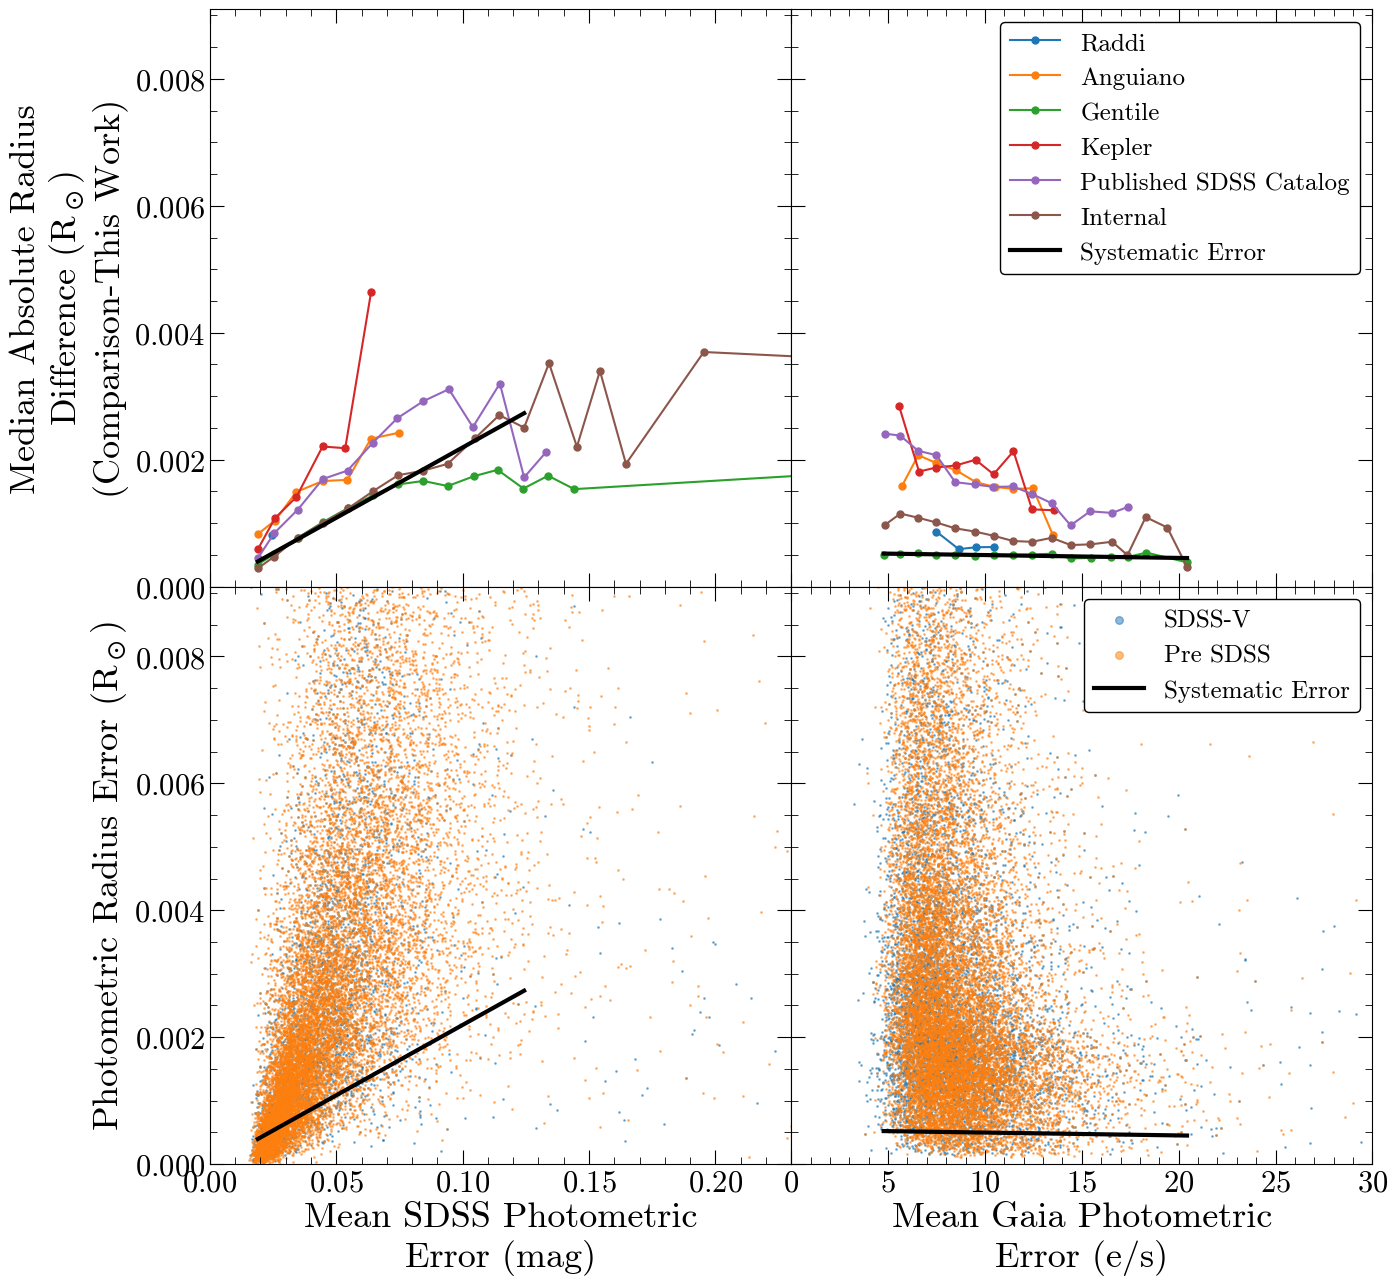

In [40]:
min_num_obs=20
    
#model the agreement as a increasing line
def line(x, a, b):
    return a*x+b

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,15))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')

#fit our SDSS phot measurements to agreement with our own Gaia measurements
name='internal'
x=mae_internal_radius_sdss.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_internal_radius_sdss.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask][:12]
y=y[nanmask][:12]

popt_radius_sdss, pcov = curve_fit(line, x, y)
def radius_sdss_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(line(snr, popt_radius_sdss[0], popt_radius_sdss[1]))
    return(result)

print(popt_radius_sdss)
aval=str(np.round(popt_radius_sdss[0],4))
bval=str(np.round(popt_radius_sdss[1],4))
print('SDSS sys uncertainty='+aval+'*x+'+bval)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_sdss[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the fitted error
ax1.plot(x,radius_sdss_err(x),'k',linewidth=3,label='Systematic Error')
ax1.set_ylabel("Median Absolute Radius\nDifference ($R_\odot$)\n(Comparison-This Work)")

#plot the radius error as a function of photometric error
ax3.scatter(SDSSV_tab_unique['phot_err_sdss'],SDSSV_tab_unique['e_radius_phot_sdss'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax3.scatter(eSDSS_tab_unique['phot_err_sdss'],eSDSS_tab_unique['e_radius_phot_sdss'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax3.plot(x,radius_sdss_err(x),'k',linewidth=3,label='Systematic Error')
ax3.set_ylabel("Photometric Radius Error ($R_\odot$)")
ax3.set_xlabel("Mean SDSS Photometric\nError (mag)")

#repeat for Gaia data

#fit our Gaia phot measurements to agreement with Gentile photometric measurements (which used Gaia phot)
name='gentile'
x=mae_gentile_radius_gaia.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_gentile_radius_gaia.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask][:18]
y=y[nanmask][:18]

popt_radius_gaia, pcov = curve_fit(line, x, y)
def radius_gaia_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(line(snr, popt_radius_gaia[0], popt_radius_gaia[1]))
    return(result)

print(popt_radius_gaia)
aval=str(np.round(popt_radius_gaia[0],4))
bval=str(np.round(popt_radius_gaia[1],4))
print('Gaia sys uncertainty='+aval+'*x+'+bval)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_gaia[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the fitted error
ax2.plot(x,radius_gaia_err(x),'k',linewidth=3,label='Systematic Error')

#plot the radius error as a function of photometric error
ax4.scatter(SDSSV_tab_unique['phot_err_gaia'],SDSSV_tab_unique['e_radius_phot_gaia'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax4.scatter(eSDSS_tab_unique['phot_err_gaia'],eSDSS_tab_unique['e_radius_phot_gaia'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax4.plot(x,radius_gaia_err(x),'k',linewidth=3,label='Systematic Error')
ax4.set_xlabel("Mean Gaia Photometric\nError (e/s)")

ax1.set_xlim(0,0.23)
ax1.set_ylim(0,0.0091)
ax3.set_xlim(0,0.23)
ax3.set_ylim(0,0.0091)

ax2.set_xlim(0,30)
ax2.set_ylim(0,0.0091)
ax4.set_xlim(0,30)
ax4.set_ylim(0,0.0091)

#hide xtick labels
ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])

#hide ytick labels
ax2.yaxis.set_ticklabels([])
ax4.yaxis.set_ticklabels([])

ax2.legend(loc='upper right')
#change the marker size manually
lgnd = ax4.legend(loc='upper right')
lgnd.legend_handles[0]._sizes = [30]
lgnd.legend_handles[1]._sizes = [30]

plt.subplots_adjust(wspace=0,hspace=0)

plt.savefig('radius_err_photerr.pdf', dpi=300)


In [43]:
print(radius_sdss_err([0]))
print(radius_sdss_err([0.005]))
print(radius_sdss_err([0.05]))
print(radius_sdss_err([0.1]))

print('')

print(np.nanmedian(SDSSV_tab_unique['phot_err_sdss']), radius_sdss_err([np.nanmedian(SDSSV_tab_unique['phot_err_sdss'])]))
print(np.nanmedian(eSDSS_tab_unique['phot_err_sdss']), radius_sdss_err([np.nanmedian(eSDSS_tab_unique['phot_err_sdss'])]))



[-2.42046961163445e-05]
[8.665320414928431e-05]
[0.0010843743065399435]
[0.0021929533091962316]

0.04632079064473915 [0.0010028004217875683]
0.0502427459476853 [0.0010897563677516198]


In [44]:
print(radius_gaia_err([1]))
print(radius_gaia_err([5]))
print(radius_gaia_err([10]))
print(radius_gaia_err([15]))

print('')

print(np.nanmedian(SDSSV_tab_unique['phot_err_gaia']), radius_gaia_err([np.nanmedian(SDSSV_tab_unique['phot_err_gaia'])]))
print(np.nanmedian(eSDSS_tab_unique['phot_err_gaia']), radius_gaia_err([np.nanmedian(eSDSS_tab_unique['phot_err_gaia'])]))


[0.0005376110464258306]
[0.0005195777560198522]
[0.000497036143012379]
[0.00047449453000490596]

7.8769805 [0.0005066073998076429]
8.063349299999999 [0.0005057671891343894]


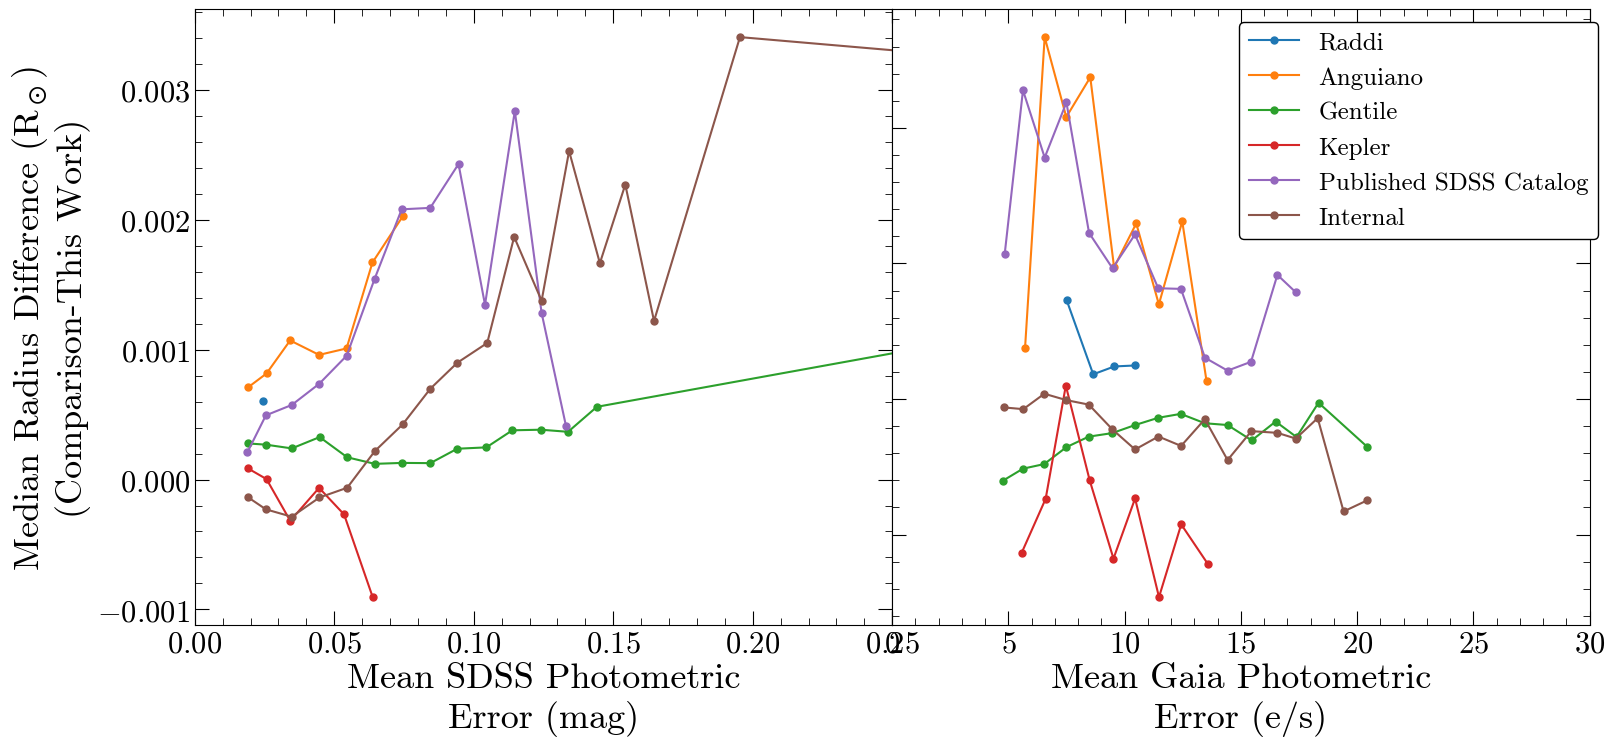

In [45]:
min_num_obs=20

fig, (ax1,ax2) =plt.subplots(1,2,figsize=(18,8))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_sdss_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_gaia_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

ax1.set_ylabel("Median Radius Difference ($R_\odot$)\n(Comparison-This Work)")
ax1.set_xlabel("Mean SDSS Photometric\nError (mag)")
ax2.set_xlabel("Mean Gaia Photometric\nError (e/s)")
ax1.set_xlim(0,0.25)
ax2.set_xlim(0,30)

ax2.legend(bbox_to_anchor=(1.03, 1))

#hide ytick labels
ax2.yaxis.set_ticklabels([])

plt.subplots_adjust(wspace=0,hspace=0)

#plt.savefig('radius_err.pdf', dpi=300)



[ 1.25704694e+00 -7.54753361e-04]
SDSS sys uncertainty=1.257*x+-0.001
[0.00017825 0.02438302]
sys uncertainty=0.0002*x+0.024


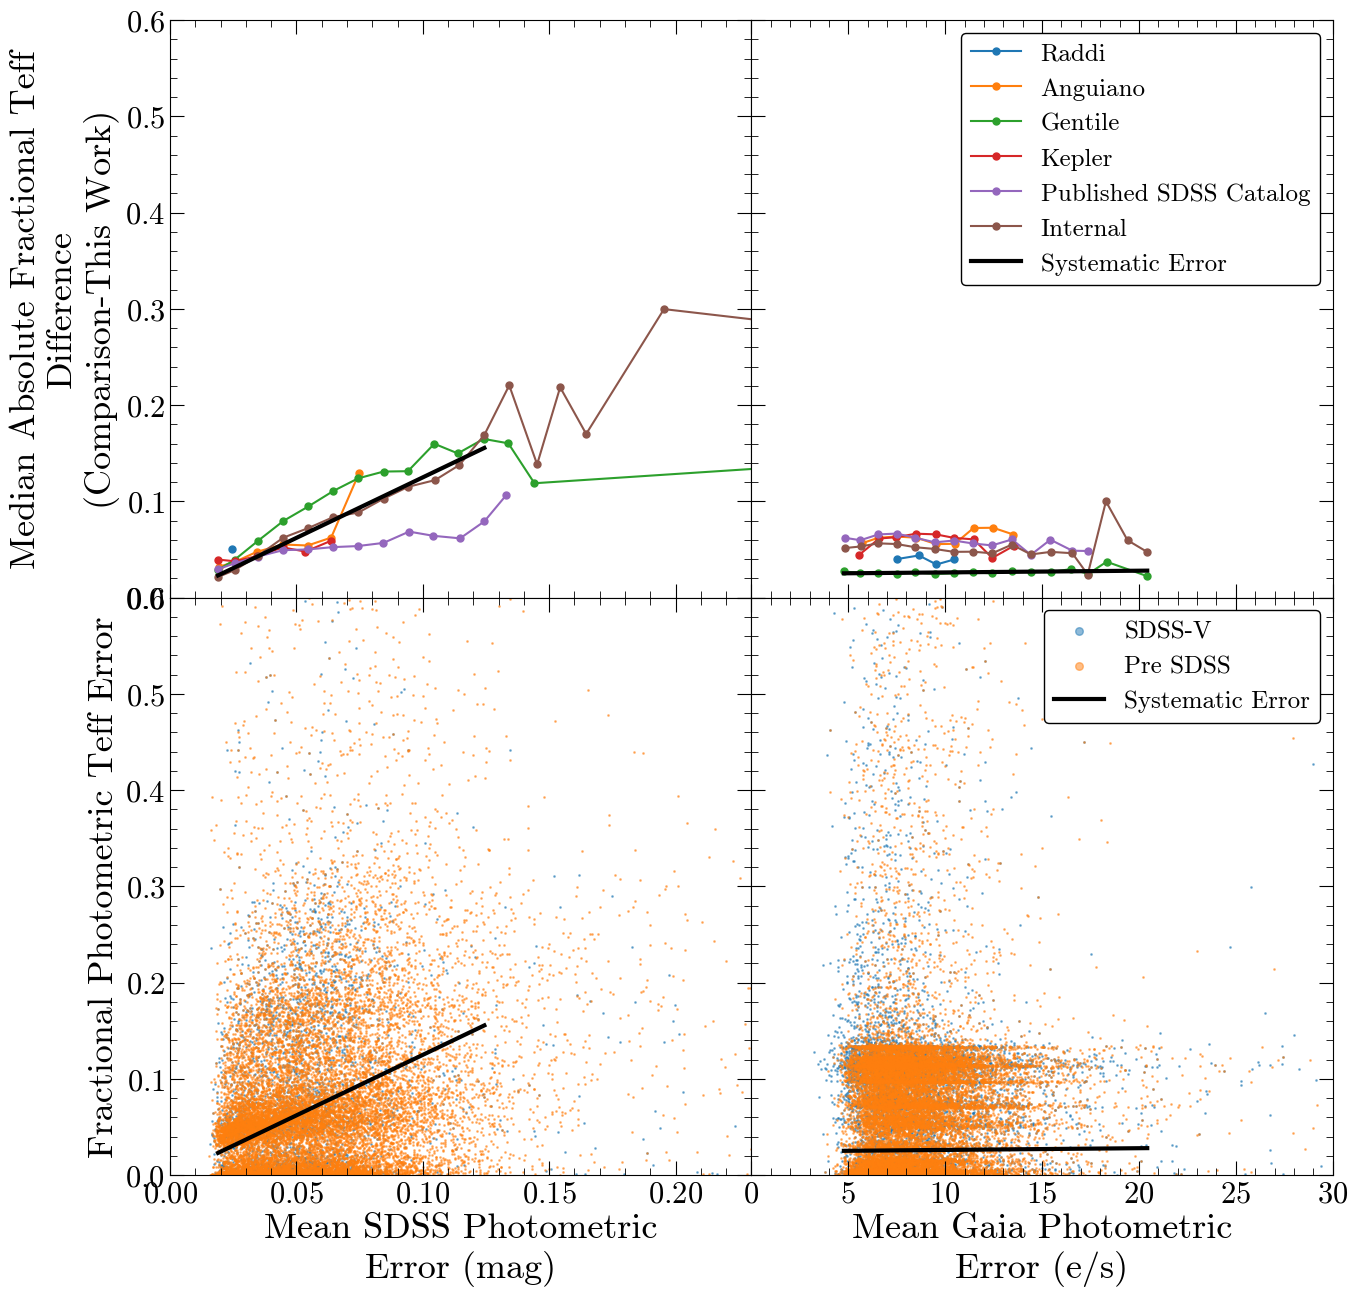

In [46]:
min_num_obs=20
    
#model the agreement as a increasing line, fit to agreement with our own Gaia measurements
def line(x, a, b):
    return a*x+b

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,15))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')

name='internal'
x=mae_internal_teff_sdss.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_internal_teff_sdss.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask][:12]
y=y[nanmask][:12]

popt_teff_sdss, pcov = curve_fit(line, x, y)
def teff_sdss_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(line(snr, popt_teff_sdss[0], popt_teff_sdss[1]))
    return(result)

print(popt_teff_sdss)
aval=str(np.round(popt_teff_sdss[0],4))
bval=str(np.round(popt_teff_sdss[1],3))
print('SDSS sys uncertainty='+aval+'*x+'+bval)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_sdss[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the fitted error
ax1.plot(x,teff_sdss_err(x),'k',linewidth=3,label='Systematic Error')
ax1.set_ylabel("Median Absolute Fractional Teff\nDifference\n(Comparison-This Work)")


#plot the teff error as a function of photometric error
ax3.scatter(SDSSV_tab_unique['phot_err_sdss'],SDSSV_tab_unique['e_teff_phot_sdss']/SDSSV_tab_unique['teff_phot_sdss'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax3.scatter(eSDSS_tab_unique['phot_err_sdss'],eSDSS_tab_unique['e_teff_phot_sdss']/eSDSS_tab_unique['teff_phot_sdss'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax3.plot(x,teff_sdss_err(x),'k',linewidth=3,label='Systematic Error')
ax3.set_ylabel("Fractional Photometric Teff Error")
ax3.set_xlabel("Mean SDSS Photometric\nError (mag)")

name='gentile'
x=mae_gentile_teff_gaia.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_gentile_teff_gaia.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask][:18]
y=y[nanmask][:18]

popt_teff_gaia, pcov = curve_fit(line, x, y)
def teff_gaia_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(line(snr, popt_teff_gaia[0], popt_teff_gaia[1]))
    return(result)

print(popt_teff_gaia)
aval=str(np.round(popt_teff_gaia[0],4))
bval=str(np.round(popt_teff_gaia[1],3))
print('sys uncertainty='+aval+'*x+'+bval)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_gaia[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the fitted error
ax2.plot(x,teff_gaia_err(x),'k',linewidth=3,label='Systematic Error')

#plot the teff error as a function of photometric error
ax4.scatter(SDSSV_tab_unique['phot_err_gaia'],SDSSV_tab_unique['e_teff_phot_gaia']/SDSSV_tab_unique['teff_phot_gaia'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax4.scatter(eSDSS_tab_unique['phot_err_gaia'],eSDSS_tab_unique['e_teff_phot_gaia']/eSDSS_tab_unique['teff_phot_gaia'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax4.plot(x,teff_gaia_err(x),'k',linewidth=3,label='Systematic Error')
ax4.set_xlabel("Mean Gaia Photometric\nError (e/s)")


ax1.set_ylim(0,0.6)
ax1.set_xlim(0,0.23)
ax3.set_ylim(0,0.6)
ax3.set_xlim(0,0.23)

ax2.set_xlim(0,30)
ax2.set_ylim(0,0.6)
ax4.set_xlim(0,30)
ax4.set_ylim(0,0.6)

#hide xtick labels
ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])

#hide ytick labels
ax2.yaxis.set_ticklabels([])
ax4.yaxis.set_ticklabels([])

ax2.legend(loc='upper right')
#change the marker size manually
lgnd = ax4.legend(loc='upper right')
lgnd.legend_handles[0]._sizes = [30]
lgnd.legend_handles[1]._sizes = [30]

plt.subplots_adjust(wspace=0,hspace=0)

plt.savefig('teff_err_photerr.pdf', dpi=300)


In [47]:
print(teff_sdss_err([0]))
print(teff_sdss_err([0.005]))
print(teff_sdss_err([0.05]))
print(teff_sdss_err([0.1]))

print('')

print(np.nanmedian(SDSSV_tab_unique['phot_err_sdss']), teff_sdss_err([np.nanmedian(SDSSV_tab_unique['phot_err_sdss'])]))
print(np.nanmedian(eSDSS_tab_unique['phot_err_sdss']), teff_sdss_err([np.nanmedian(eSDSS_tab_unique['phot_err_sdss'])]))



[-0.0007547533609926589]
[0.005530481358665897]
[0.0620975938355929]
[0.12494994103217845]

0.04632079064473915 [0.05747265495947729]
0.0502427459476853 [0.062402736887282505]


In [48]:
print(teff_gaia_err([1]))
print(teff_gaia_err([5]))
print(teff_gaia_err([10]))
print(teff_gaia_err([15]))

print('')

print(np.nanmedian(SDSSV_tab_unique['phot_err_gaia']), teff_gaia_err([np.nanmedian(SDSSV_tab_unique['phot_err_gaia'])]))
print(np.nanmedian(eSDSS_tab_unique['phot_err_gaia']), teff_gaia_err([np.nanmedian(eSDSS_tab_unique['phot_err_gaia'])]))




[0.02456126987994874]
[0.025274275609156724]
[0.02616553277066671]
[0.02705678993217669]

7.8769805 [0.02578710150398664]
8.063349299999999 [0.025820322009523045]


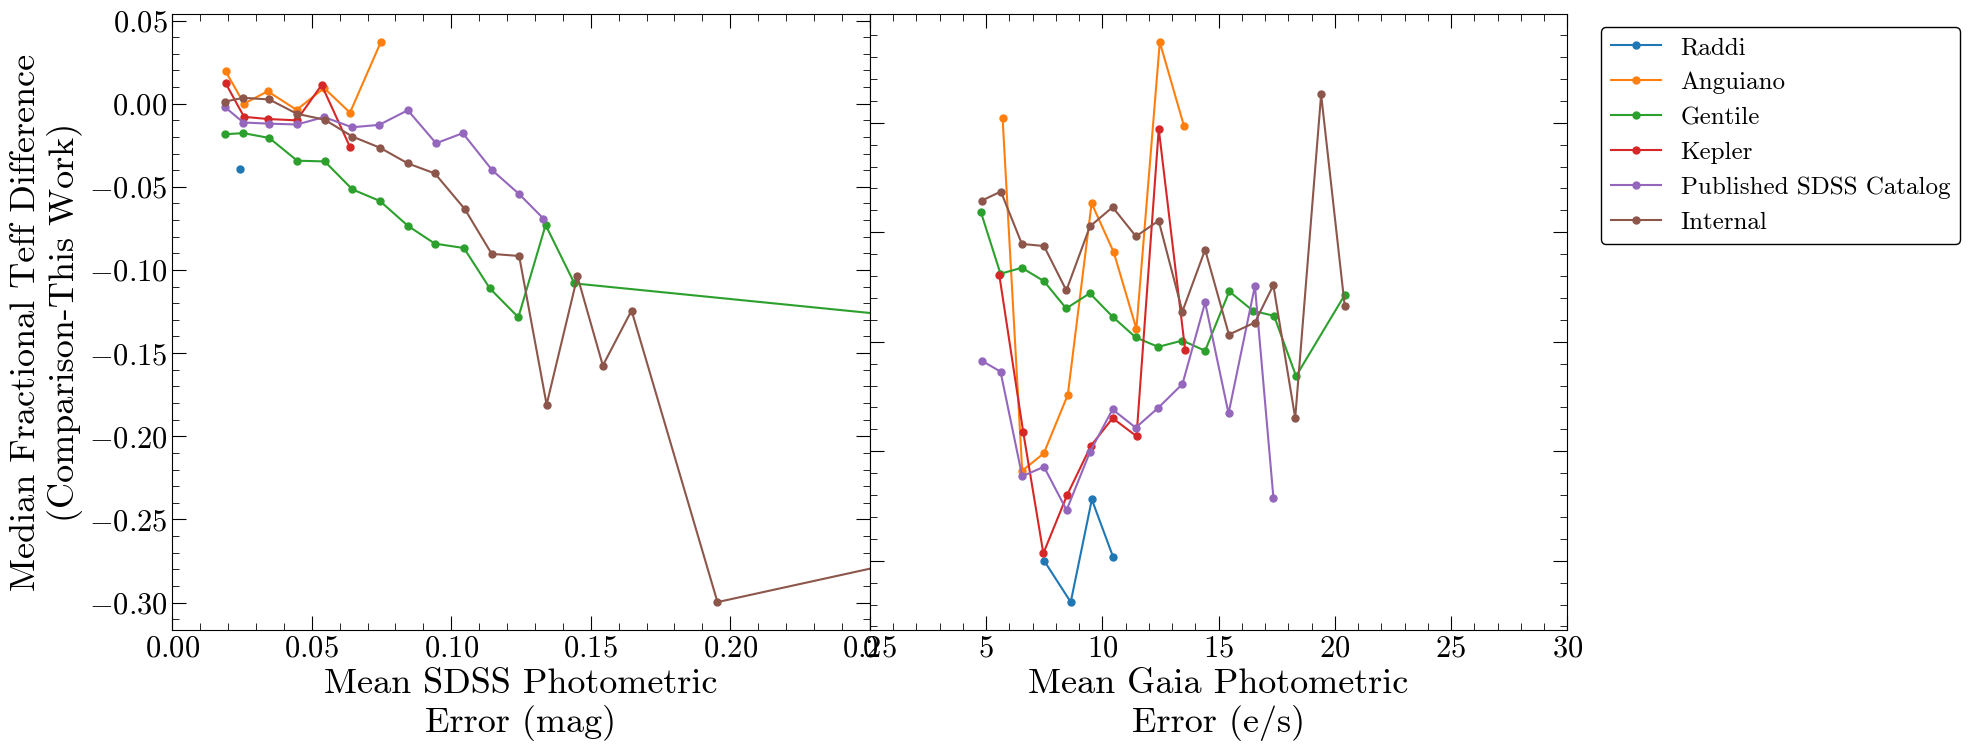

In [49]:
min_num_obs=20

fig, (ax1,ax2) =plt.subplots(1,2,figsize=(18,8))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_sdss_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_teff_gaia_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

ax1.set_ylabel("Median Fractional Teff Difference\n(Comparison-This Work)")
ax1.set_xlabel("Mean SDSS Photometric\nError (mag)")
ax2.set_xlabel("Mean Gaia Photometric\nError (e/s)")
ax1.set_xlim(0,0.25)
ax2.set_xlim(0,30)

ax2.legend(bbox_to_anchor=(1.03, 1))

#hide ytick labels
ax2.yaxis.set_ticklabels([])

plt.subplots_adjust(wspace=0,hspace=0)

#plt.savefig('teff_err.pdf', dpi=300)




In [50]:
radius_bins=np.arange(0,0.052,0.002)
teff_bins=np.arange(1000,131000,1000)

In [51]:
#whether to implement radius_phot<0.015 cut for teff measurements
#and phot_err_sdss<0.1 or phot_err_gaia<20 cuts
rad_cut=True

In [52]:
if rad_cut:
    #calculate the radius differences binned in radius for sdss photometric measurements
    mae_raddi_radius_radius_sdss=binned_diff('raddi','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_anguiano_radius_radius_sdss=binned_diff('anguiano','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_gentile_radius_radius_sdss=binned_diff('gentile','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_kepler_radius_radius_sdss=binned_diff('kepler','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_sdss_radius_radius_sdss=binned_diff('sdss_dr','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_internal_radius_radius_sdss=binned_diff('internal','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')

    #calculate the radius differences binned in radius for gaia photometric measurements
    mae_raddi_radius_radius_gaia=binned_diff('raddi','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_anguiano_radius_radius_gaia=binned_diff('anguiano','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_gentile_radius_radius_gaia=binned_diff('gentile','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_kepler_radius_radius_gaia=binned_diff('kepler','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_sdss_radius_radius_gaia=binned_diff('sdss_dr','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_internal_radius_radius_gaia=binned_diff('internal','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')

    #calculate the radius differences binned in teff for sdss photometric measurements
    mae_raddi_radius_teff_sdss=binned_diff('raddi','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_anguiano_radius_teff_sdss=binned_diff('anguiano','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_gentile_radius_teff_sdss=binned_diff('gentile','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_kepler_radius_teff_sdss=binned_diff('kepler','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_sdss_radius_teff_sdss=binned_diff('sdss_dr','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_internal_radius_teff_sdss=binned_diff('internal','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')

    #calculate the radius differences binned in teff for gaia photometric measurements
    mae_raddi_radius_teff_gaia=binned_diff('raddi','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_anguiano_radius_teff_gaia=binned_diff('anguiano','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_gentile_radius_teff_gaia=binned_diff('gentile','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_kepler_radius_teff_gaia=binned_diff('kepler','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_sdss_radius_teff_gaia=binned_diff('sdss_dr','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_internal_radius_teff_gaia=binned_diff('internal','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')

else:
    #calculate the radius differences binned in radius for sdss photometric measurements
    mae_raddi_radius_radius_sdss=binned_diff('raddi','sdss','radius','radius_phot_sdss',radius_bins)
    mae_anguiano_radius_radius_sdss=binned_diff('anguiano','sdss','radius','radius_phot_sdss',radius_bins)
    mae_gentile_radius_radius_sdss=binned_diff('gentile','sdss','radius','radius_phot_sdss',radius_bins)
    mae_kepler_radius_radius_sdss=binned_diff('kepler','sdss','radius','radius_phot_sdss',radius_bins)
    mae_sdss_radius_radius_sdss=binned_diff('sdss_dr','sdss','radius','radius_phot_sdss',radius_bins)
    mae_internal_radius_radius_sdss=binned_diff('internal','sdss','radius','radius_phot_sdss',radius_bins)

    #calculate the radius differences binned in radius for gaia photometric measurements
    mae_raddi_radius_radius_gaia=binned_diff('raddi','gaia','radius','radius_phot_gaia',radius_bins)
    mae_anguiano_radius_radius_gaia=binned_diff('anguiano','gaia','radius','radius_phot_gaia',radius_bins)
    mae_gentile_radius_radius_gaia=binned_diff('gentile','gaia','radius','radius_phot_gaia',radius_bins)
    mae_kepler_radius_radius_gaia=binned_diff('kepler','gaia','radius','radius_phot_gaia',radius_bins)
    mae_sdss_radius_radius_gaia=binned_diff('sdss_dr','gaia','radius','radius_phot_gaia',radius_bins)
    mae_internal_radius_radius_gaia=binned_diff('internal','gaia','radius','radius_phot_gaia',radius_bins)

    #calculate the radius differences binned in teff for sdss photometric measurements
    mae_raddi_radius_teff_sdss=binned_diff('raddi','sdss','radius','teff_phot_sdss',teff_bins)
    mae_anguiano_radius_teff_sdss=binned_diff('anguiano','sdss','radius','teff_phot_sdss',teff_bins)
    mae_gentile_radius_teff_sdss=binned_diff('gentile','sdss','radius','teff_phot_sdss',teff_bins)
    mae_kepler_radius_teff_sdss=binned_diff('kepler','sdss','radius','teff_phot_sdss',teff_bins)
    mae_sdss_radius_teff_sdss=binned_diff('sdss_dr','sdss','radius','teff_phot_sdss',teff_bins)
    mae_internal_radius_teff_sdss=binned_diff('internal','sdss','radius','teff_phot_sdss',teff_bins)

    #calculate the radius differences binned in teff for gaia photometric measurements
    mae_raddi_radius_teff_gaia=binned_diff('raddi','gaia','radius','teff_phot_gaia',teff_bins)
    mae_anguiano_radius_teff_gaia=binned_diff('anguiano','gaia','radius','teff_phot_gaia',teff_bins)
    mae_gentile_radius_teff_gaia=binned_diff('gentile','gaia','radius','teff_phot_gaia',teff_bins)
    mae_kepler_radius_teff_gaia=binned_diff('kepler','gaia','radius','teff_phot_gaia',teff_bins)
    mae_sdss_radius_teff_gaia=binned_diff('sdss_dr','gaia','radius','teff_phot_gaia',teff_bins)
    mae_internal_radius_teff_gaia=binned_diff('internal','gaia','radius','teff_phot_gaia',teff_bins)


In [53]:
if rad_cut:
    #calculate the radius differences binned in radius for sdss photometric measurements
    med_raddi_radius_radius_sdss=binned_diff('raddi','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_anguiano_radius_radius_sdss=binned_diff('anguiano','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_gentile_radius_radius_sdss=binned_diff('gentile','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_kepler_radius_radius_sdss=binned_diff('kepler','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_sdss_radius_radius_sdss=binned_diff('sdss_dr','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_internal_radius_radius_sdss=binned_diff('internal','sdss','radius','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)

    #calculate the radius differences binned in radius for gaia photometric measurements
    med_raddi_radius_radius_gaia=binned_diff('raddi','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_anguiano_radius_radius_gaia=binned_diff('anguiano','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_gentile_radius_radius_gaia=binned_diff('gentile','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_kepler_radius_radius_gaia=binned_diff('kepler','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_sdss_radius_radius_gaia=binned_diff('sdss_dr','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_internal_radius_radius_gaia=binned_diff('internal','gaia','radius','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)

    #calculate the radius differences binned in teff for sdss photometric measurements
    med_raddi_radius_teff_sdss=binned_diff('raddi','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_anguiano_radius_teff_sdss=binned_diff('anguiano','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_gentile_radius_teff_sdss=binned_diff('gentile','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_kepler_radius_teff_sdss=binned_diff('kepler','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_sdss_radius_teff_sdss=binned_diff('sdss_dr','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_internal_radius_teff_sdss=binned_diff('internal','sdss','radius','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)

    #calculate the radius differences binned in teff for gaia photometric measurements
    med_raddi_radius_teff_gaia=binned_diff('raddi','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_anguiano_radius_teff_gaia=binned_diff('anguiano','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_gentile_radius_teff_gaia=binned_diff('gentile','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_kepler_radius_teff_gaia=binned_diff('kepler','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_sdss_radius_teff_gaia=binned_diff('sdss_dr','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_internal_radius_teff_gaia=binned_diff('internal','gaia','radius','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)

else:
    #calculate the radius differences binned in radius for sdss photometric measurements
    med_raddi_radius_radius_sdss=binned_diff('raddi','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)
    med_anguiano_radius_radius_sdss=binned_diff('anguiano','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)
    med_gentile_radius_radius_sdss=binned_diff('gentile','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)
    med_kepler_radius_radius_sdss=binned_diff('kepler','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)
    med_sdss_radius_radius_sdss=binned_diff('sdss_dr','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)
    med_internal_radius_radius_sdss=binned_diff('internal','sdss','radius','radius_phot_sdss',radius_bins,absolute_val=False)

    #calculate the radius differences binned in radius for gaia photometric measurements
    med_raddi_radius_radius_gaia=binned_diff('raddi','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)
    med_anguiano_radius_radius_gaia=binned_diff('anguiano','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)
    med_gentile_radius_radius_gaia=binned_diff('gentile','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)
    med_kepler_radius_radius_gaia=binned_diff('kepler','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)
    med_sdss_radius_radius_gaia=binned_diff('sdss_dr','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)
    med_internal_radius_radius_gaia=binned_diff('internal','gaia','radius','radius_phot_gaia',radius_bins,absolute_val=False)

    #calculate the radius differences binned in teff for sdss photometric measurements
    med_raddi_radius_teff_sdss=binned_diff('raddi','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)
    med_anguiano_radius_teff_sdss=binned_diff('anguiano','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)
    med_gentile_radius_teff_sdss=binned_diff('gentile','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)
    med_kepler_radius_teff_sdss=binned_diff('kepler','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)
    med_sdss_radius_teff_sdss=binned_diff('sdss_dr','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)
    med_internal_radius_teff_sdss=binned_diff('internal','sdss','radius','teff_phot_sdss',teff_bins,absolute_val=False)

    #calculate the radius differences binned in teff for gaia photometric measurements
    med_raddi_radius_teff_gaia=binned_diff('raddi','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)
    med_anguiano_radius_teff_gaia=binned_diff('anguiano','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)
    med_gentile_radius_teff_gaia=binned_diff('gentile','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)
    med_kepler_radius_teff_gaia=binned_diff('kepler','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)
    med_sdss_radius_teff_gaia=binned_diff('sdss_dr','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)
    med_internal_radius_teff_gaia=binned_diff('internal','gaia','radius','teff_phot_gaia',teff_bins,absolute_val=False)


In [54]:
if rad_cut:
    #calculate the teff differences binned in radius for sdss photometric measurements
    mae_raddi_teff_radius_sdss=binned_diff('raddi','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_anguiano_teff_radius_sdss=binned_diff('anguiano','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_gentile_teff_radius_sdss=binned_diff('gentile','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_kepler_teff_radius_sdss=binned_diff('kepler','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_sdss_teff_radius_sdss=binned_diff('sdss_dr','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')
    mae_internal_teff_radius_sdss=binned_diff('internal','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1')

    #calculate the teff differences binned in radius for gaia photometric measurements
    mae_raddi_teff_radius_gaia=binned_diff('raddi','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_anguiano_teff_radius_gaia=binned_diff('anguiano','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_gentile_teff_radius_gaia=binned_diff('gentile','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_kepler_teff_radius_gaia=binned_diff('kepler','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_sdss_teff_radius_gaia=binned_diff('sdss_dr','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')
    mae_internal_teff_radius_gaia=binned_diff('internal','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20')

    #calculate the teff differences binned in teff for sdss photometric measurements
    mae_raddi_teff_teff_sdss=binned_diff('raddi','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_anguiano_teff_teff_sdss=binned_diff('anguiano','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_gentile_teff_teff_sdss=binned_diff('gentile','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_kepler_teff_teff_sdss=binned_diff('kepler','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_sdss_teff_teff_sdss=binned_diff('sdss_dr','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')
    mae_internal_teff_teff_sdss=binned_diff('internal','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015')

    #calculate the teff differences binned in teff for gaia photometric measurements
    mae_raddi_teff_teff_gaia=binned_diff('raddi','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_anguiano_teff_teff_gaia=binned_diff('anguiano','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_gentile_teff_teff_gaia=binned_diff('gentile','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_kepler_teff_teff_gaia=binned_diff('kepler','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_sdss_teff_teff_gaia=binned_diff('sdss_dr','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')
    mae_internal_teff_teff_gaia=binned_diff('internal','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015')

else:
    #calculate the teff differences binned in radius for sdss photometric measurements
    mae_raddi_teff_radius_sdss=binned_diff('raddi','sdss','teff','radius_phot_sdss',radius_bins)
    mae_anguiano_teff_radius_sdss=binned_diff('anguiano','sdss','teff','radius_phot_sdss',radius_bins)
    mae_gentile_teff_radius_sdss=binned_diff('gentile','sdss','teff','radius_phot_sdss',radius_bins)
    mae_kepler_teff_radius_sdss=binned_diff('kepler','sdss','teff','radius_phot_sdss',radius_bins)
    mae_sdss_teff_radius_sdss=binned_diff('sdss_dr','sdss','teff','radius_phot_sdss',radius_bins)
    mae_internal_teff_radius_sdss=binned_diff('internal','sdss','teff','radius_phot_sdss',radius_bins)

    #calculate the teff differences binned in radius for gaia photometric measurements
    mae_raddi_teff_radius_gaia=binned_diff('raddi','gaia','teff','radius_phot_gaia',radius_bins)
    mae_anguiano_teff_radius_gaia=binned_diff('anguiano','gaia','teff','radius_phot_gaia',radius_bins)
    mae_gentile_teff_radius_gaia=binned_diff('gentile','gaia','teff','radius_phot_gaia',radius_bins)
    mae_kepler_teff_radius_gaia=binned_diff('kepler','gaia','teff','radius_phot_gaia',radius_bins)
    mae_sdss_teff_radius_gaia=binned_diff('sdss_dr','gaia','teff','radius_phot_gaia',radius_bins)
    mae_internal_teff_radius_gaia=binned_diff('internal','gaia','teff','radius_phot_gaia',radius_bins)

    #calculate the teff differences binned in teff for sdss photometric measurements
    mae_raddi_teff_teff_sdss=binned_diff('raddi','sdss','teff','teff_phot_sdss',teff_bins)
    mae_anguiano_teff_teff_sdss=binned_diff('anguiano','sdss','teff','teff_phot_sdss',teff_bins)
    mae_gentile_teff_teff_sdss=binned_diff('gentile','sdss','teff','teff_phot_sdss',teff_bins)
    mae_kepler_teff_teff_sdss=binned_diff('kepler','sdss','teff','teff_phot_sdss',teff_bins)
    mae_sdss_teff_teff_sdss=binned_diff('sdss_dr','sdss','teff','teff_phot_sdss',teff_bins)
    mae_internal_teff_teff_sdss=binned_diff('internal','sdss','teff','teff_phot_sdss',teff_bins)

    #calculate the teff differences binned in teff for gaia photometric measurements
    mae_raddi_teff_teff_gaia=binned_diff('raddi','gaia','teff','teff_phot_gaia',teff_bins)
    mae_anguiano_teff_teff_gaia=binned_diff('anguiano','gaia','teff','teff_phot_gaia',teff_bins)
    mae_gentile_teff_teff_gaia=binned_diff('gentile','gaia','teff','teff_phot_gaia',teff_bins)
    mae_kepler_teff_teff_gaia=binned_diff('kepler','gaia','teff','teff_phot_gaia',teff_bins)
    mae_sdss_teff_teff_gaia=binned_diff('sdss_dr','gaia','teff','teff_phot_gaia',teff_bins)
    mae_internal_teff_teff_gaia=binned_diff('internal','gaia','teff','teff_phot_gaia',teff_bins)


In [55]:
if rad_cut:
    #calculate the teff differences binned in radius for sdss photometric measurements
    med_raddi_teff_radius_sdss=binned_diff('raddi','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_anguiano_teff_radius_sdss=binned_diff('anguiano','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_gentile_teff_radius_sdss=binned_diff('gentile','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_kepler_teff_radius_sdss=binned_diff('kepler','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_sdss_teff_radius_sdss=binned_diff('sdss_dr','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)
    med_internal_teff_radius_sdss=binned_diff('internal','sdss','teff','radius_phot_sdss',radius_bins,cut_param='phot_err_sdss',cut='<0.1',absolute_val=False)

    #calculate the teff differences binned in radius for gaia photometric measurements
    med_raddi_teff_radius_gaia=binned_diff('raddi','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_anguiano_teff_radius_gaia=binned_diff('anguiano','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_gentile_teff_radius_gaia=binned_diff('gentile','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_kepler_teff_radius_gaia=binned_diff('kepler','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_sdss_teff_radius_gaia=binned_diff('sdss_dr','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)
    med_internal_teff_radius_gaia=binned_diff('internal','gaia','teff','radius_phot_gaia',radius_bins,cut_param='phot_err_gaia',cut='<20',absolute_val=False)

    #calculate the teff differences binned in teff for sdss photometric measurements
    med_raddi_teff_teff_sdss=binned_diff('raddi','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_anguiano_teff_teff_sdss=binned_diff('anguiano','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_gentile_teff_teff_sdss=binned_diff('gentile','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_kepler_teff_teff_sdss=binned_diff('kepler','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_sdss_teff_teff_sdss=binned_diff('sdss_dr','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)
    med_internal_teff_teff_sdss=binned_diff('internal','sdss','teff','teff_phot_sdss',teff_bins,cut_param='phot_err_sdss',cut='<0.1',cut_param2='radius_phot_sdss',cut2='<0.015',absolute_val=False)

    #calculate the teff differences binned in teff for gaia photometric measurements
    med_raddi_teff_teff_gaia=binned_diff('raddi','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_anguiano_teff_teff_gaia=binned_diff('anguiano','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_gentile_teff_teff_gaia=binned_diff('gentile','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_kepler_teff_teff_gaia=binned_diff('kepler','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_sdss_teff_teff_gaia=binned_diff('sdss_dr','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)
    med_internal_teff_teff_gaia=binned_diff('internal','gaia','teff','teff_phot_gaia',teff_bins,cut_param='phot_err_gaia',cut='<20',cut_param2='radius_phot_gaia',cut2='<0.015',absolute_val=False)

else:
    #calculate the teff differences binned in radius for sdss photometric measurements
    med_raddi_teff_radius_sdss=binned_diff('raddi','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)
    med_anguiano_teff_radius_sdss=binned_diff('anguiano','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)
    med_gentile_teff_radius_sdss=binned_diff('gentile','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)
    med_kepler_teff_radius_sdss=binned_diff('kepler','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)
    med_sdss_teff_radius_sdss=binned_diff('sdss_dr','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)
    med_internal_teff_radius_sdss=binned_diff('internal','sdss','teff','radius_phot_sdss',radius_bins,absolute_val=False)

    #calculate the teff differences binned in radius for gaia photometric measurements
    med_raddi_teff_radius_gaia=binned_diff('raddi','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)
    med_anguiano_teff_radius_gaia=binned_diff('anguiano','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)
    med_gentile_teff_radius_gaia=binned_diff('gentile','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)
    med_kepler_teff_radius_gaia=binned_diff('kepler','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)
    med_sdss_teff_radius_gaia=binned_diff('sdss_dr','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)
    med_internal_teff_radius_gaia=binned_diff('internal','gaia','teff','radius_phot_gaia',radius_bins,absolute_val=False)

    #calculate the teff differences binned in teff for sdss photometric measurements
    med_raddi_teff_teff_sdss=binned_diff('raddi','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)
    med_anguiano_teff_teff_sdss=binned_diff('anguiano','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)
    med_gentile_teff_teff_sdss=binned_diff('gentile','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)
    med_kepler_teff_teff_sdss=binned_diff('kepler','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)
    med_sdss_teff_teff_sdss=binned_diff('sdss_dr','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)
    med_internal_teff_teff_sdss=binned_diff('internal','sdss','teff','teff_phot_sdss',teff_bins,absolute_val=False)

    #calculate the teff differences binned in teff for gaia photometric measurements
    med_raddi_teff_teff_gaia=binned_diff('raddi','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)
    med_anguiano_teff_teff_gaia=binned_diff('anguiano','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)
    med_gentile_teff_teff_gaia=binned_diff('gentile','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)
    med_kepler_teff_teff_gaia=binned_diff('kepler','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)
    med_sdss_teff_teff_gaia=binned_diff('sdss_dr','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)
    med_internal_teff_teff_gaia=binned_diff('internal','gaia','teff','teff_phot_gaia',teff_bins,absolute_val=False)


In [56]:
names=['raddi','anguiano','gentile','kepler','sdss_dr','internal']
labels=['Raddi','Anguiano','Gentile','Kepler','Published SDSS Catalog','Internal']
dataframes_radius_radius_sdss=[mae_raddi_radius_radius_sdss,mae_anguiano_radius_radius_sdss,mae_gentile_radius_radius_sdss,mae_kepler_radius_radius_sdss,mae_sdss_radius_radius_sdss,mae_internal_radius_radius_sdss]
dataframes_radius_radius_gaia=[mae_raddi_radius_radius_gaia,mae_anguiano_radius_radius_gaia,mae_gentile_radius_radius_gaia,mae_kepler_radius_radius_gaia,mae_sdss_radius_radius_gaia,mae_internal_radius_radius_gaia]

dataframes_radius_teff_sdss=[mae_raddi_radius_teff_sdss,mae_anguiano_radius_teff_sdss,mae_gentile_radius_teff_sdss,mae_kepler_radius_teff_sdss,mae_sdss_radius_teff_sdss,mae_internal_radius_teff_sdss]
dataframes_radius_teff_gaia=[mae_raddi_radius_teff_gaia,mae_anguiano_radius_teff_gaia,mae_gentile_radius_teff_gaia,mae_kepler_radius_teff_gaia,mae_sdss_radius_teff_gaia,mae_internal_radius_teff_gaia]

dataframes_teff_radius_sdss=[mae_raddi_teff_radius_sdss,mae_anguiano_teff_radius_sdss,mae_gentile_teff_radius_sdss,mae_kepler_teff_radius_sdss,mae_sdss_teff_radius_sdss,mae_internal_teff_radius_sdss]
dataframes_teff_radius_gaia=[mae_raddi_teff_radius_gaia,mae_anguiano_teff_radius_gaia,mae_gentile_teff_radius_gaia,mae_kepler_teff_radius_gaia,mae_sdss_teff_radius_gaia,mae_internal_teff_radius_gaia]
    
dataframes_teff_teff_sdss=[mae_raddi_teff_teff_sdss,mae_anguiano_teff_teff_sdss,mae_gentile_teff_teff_sdss,mae_kepler_teff_teff_sdss,mae_sdss_teff_teff_sdss,mae_internal_teff_teff_sdss]
dataframes_teff_teff_gaia=[mae_raddi_teff_teff_gaia,mae_anguiano_teff_teff_gaia,mae_gentile_teff_teff_gaia,mae_kepler_teff_teff_gaia,mae_sdss_teff_teff_gaia,mae_internal_teff_teff_gaia]

dataframes_radius_radius_sdss_med=[med_raddi_radius_radius_sdss,med_anguiano_radius_radius_sdss,med_gentile_radius_radius_sdss,med_kepler_radius_radius_sdss,med_sdss_radius_radius_sdss,med_internal_radius_radius_sdss]
dataframes_radius_radius_gaia_med=[med_raddi_radius_radius_gaia,med_anguiano_radius_radius_gaia,med_gentile_radius_radius_gaia,med_kepler_radius_radius_gaia,med_sdss_radius_radius_gaia,med_internal_radius_radius_gaia]

dataframes_radius_teff_sdss_med=[med_raddi_radius_teff_sdss,med_anguiano_radius_teff_sdss,med_gentile_radius_teff_sdss,med_kepler_radius_teff_sdss,med_sdss_radius_teff_sdss,med_internal_radius_teff_sdss]
dataframes_radius_teff_gaia_med=[med_raddi_radius_teff_gaia,med_anguiano_radius_teff_gaia,med_gentile_radius_teff_gaia,med_kepler_radius_teff_gaia,med_sdss_radius_teff_gaia,med_internal_radius_teff_gaia]

dataframes_teff_radius_sdss_med=[med_raddi_teff_radius_sdss,med_anguiano_teff_radius_sdss,med_gentile_teff_radius_sdss,med_kepler_teff_radius_sdss,med_sdss_teff_radius_sdss,med_internal_teff_radius_sdss]
dataframes_teff_radius_gaia_med=[med_raddi_teff_radius_gaia,med_anguiano_teff_radius_gaia,med_gentile_teff_radius_gaia,med_kepler_teff_radius_gaia,med_sdss_teff_radius_gaia,med_internal_teff_radius_gaia]
    
dataframes_teff_teff_sdss_med=[med_raddi_teff_teff_sdss,med_anguiano_teff_teff_sdss,med_gentile_teff_teff_sdss,med_kepler_teff_teff_sdss,med_sdss_teff_teff_sdss,med_internal_teff_teff_sdss]
dataframes_teff_teff_gaia_med=[med_raddi_teff_teff_gaia,med_anguiano_teff_teff_gaia,med_gentile_teff_teff_gaia,med_kepler_teff_teff_gaia,med_sdss_teff_teff_gaia,med_internal_teff_teff_gaia]


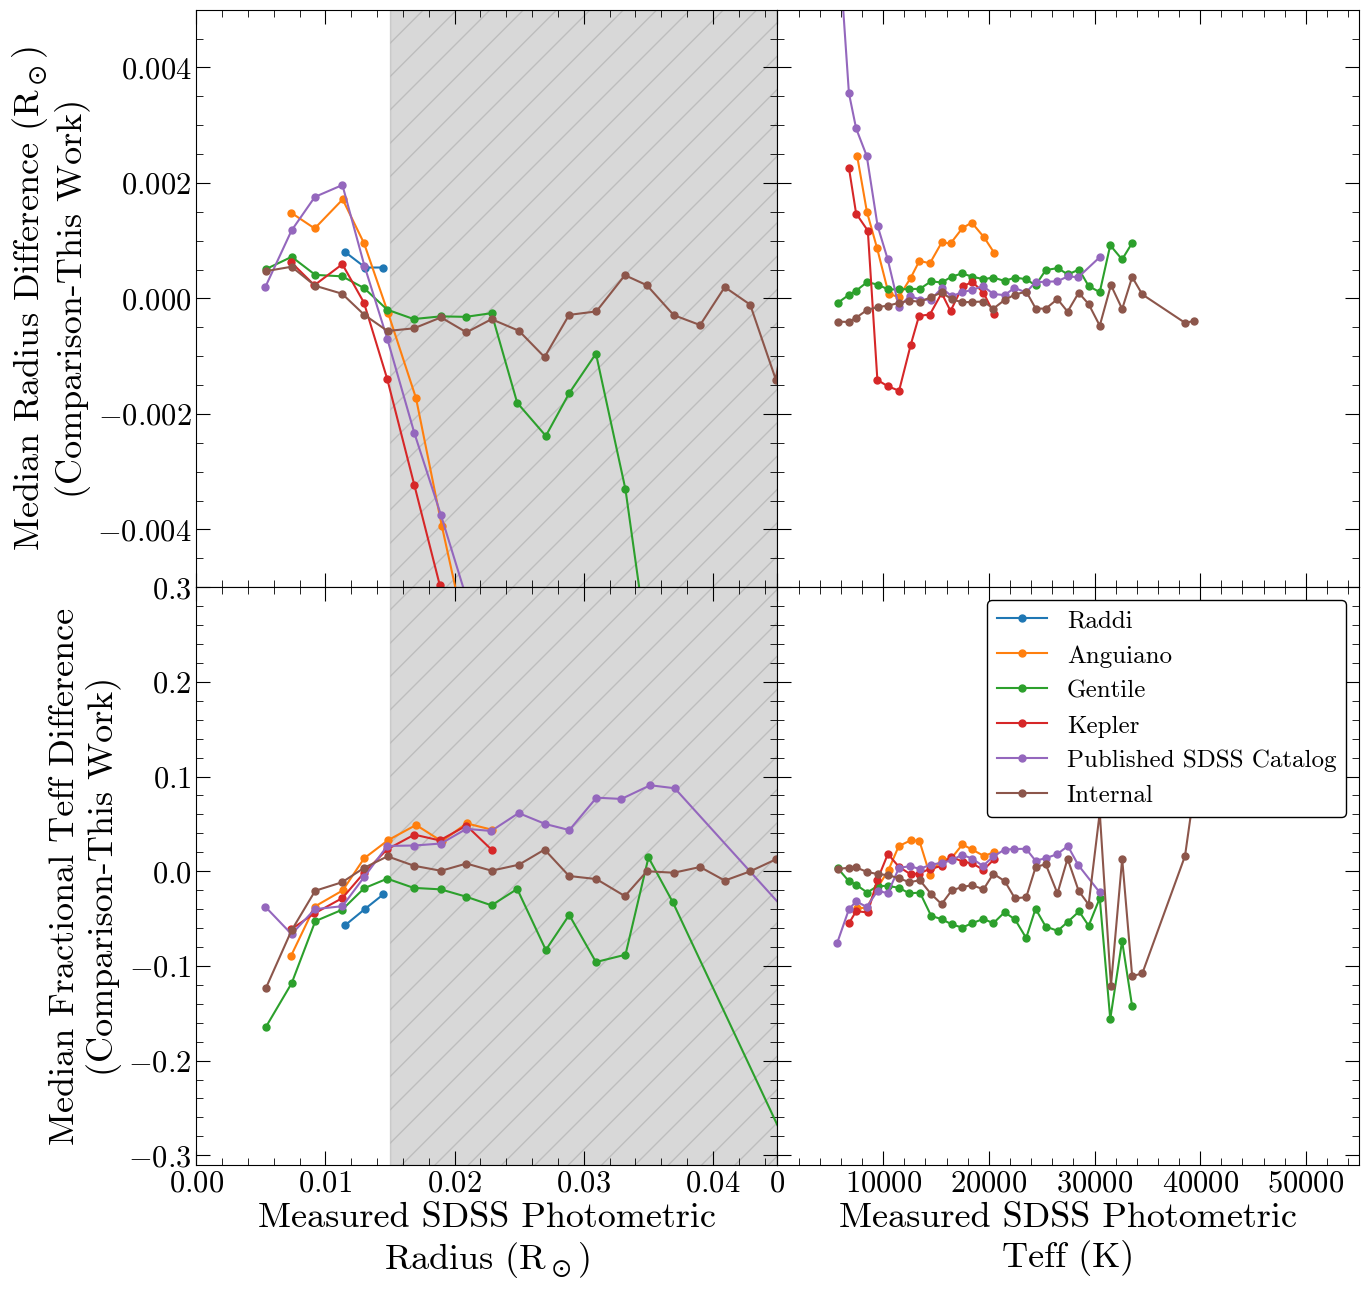

In [57]:
min_num_obs=20

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,15))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_radius_sdss_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_radius_teff_sdss_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_teff_radius_sdss_med[i]
    ax3.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_teff_teff_sdss_med[i]
    ax4.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
    
#exclude Binary Evolution
ax1.axvspan(0.015, 0.05, hatch ='/', color = 'grey', alpha = 0.3,label='Binary Evolution')
ax3.axvspan(0.015, 0.05, hatch ='/', color = 'grey', alpha = 0.3,label='Binary Evolution')

ax1.set_ylabel("Median Radius Difference ($R_\odot$)\n(Comparison-This Work)")
ax3.set_ylabel("Median Fractional Teff Difference\n(Comparison-This Work)")
ax3.set_xlabel("Measured SDSS Photometric\nRadius ($R_\odot$)")
ax4.set_xlabel("Measured SDSS Photometric\nTeff (K)")

ax1.set_xlim(0,0.045)
ax3.set_xlim(0,0.045)

ax2.set_xlim(0,55000)
ax4.set_xlim(0,55000)

#make y limits consistent
ax1.set_ylim(-0.005,0.005)
ax2.set_ylim(-0.005,0.005)
#hide tick labels
ax2.yaxis.set_ticklabels([])

#make y limits consistent
ax3.set_ylim(-0.31,0.3)
ax4.set_ylim(-0.31,0.3)
#hide tick labels
ax4.yaxis.set_ticklabels([])

#hide xtick labels
ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])

#ax2.legend(loc='upper right',bbox_to_anchor=(1.73, 1))
ax4.legend(loc='upper right')

plt.subplots_adjust(wspace=0,hspace=0)

plt.savefig('phot_err_sdss.pdf', dpi=300)


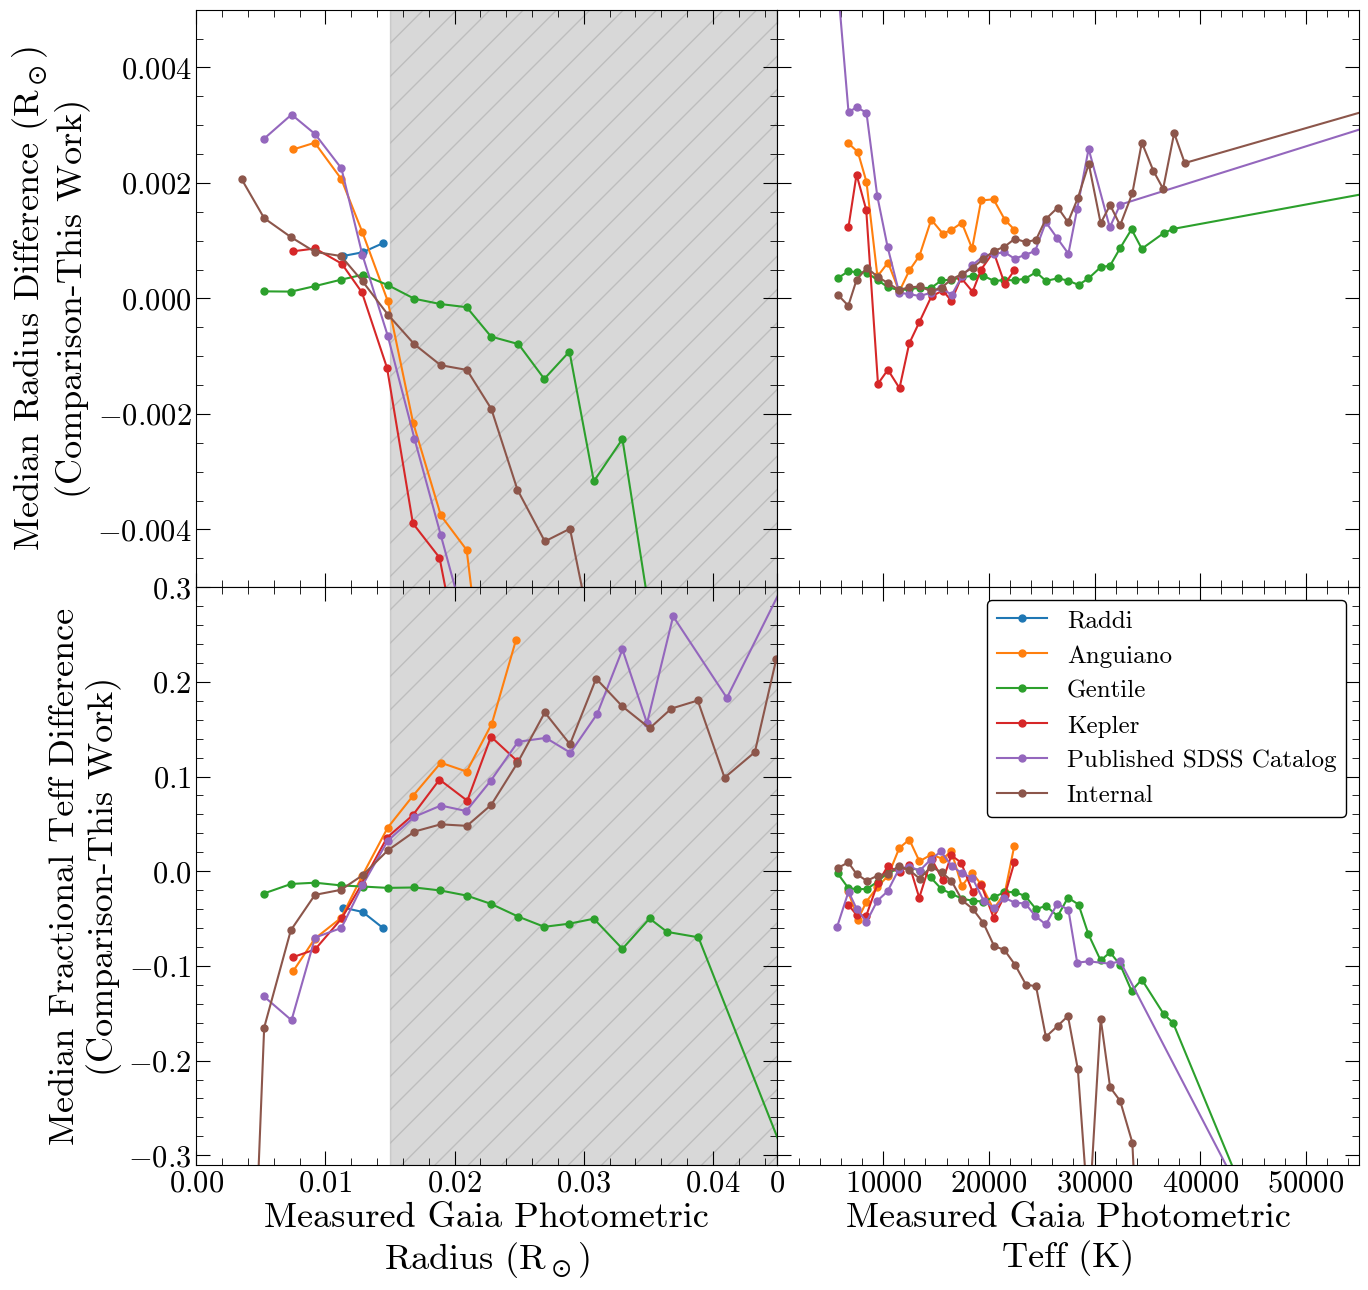

In [58]:
min_num_obs=20

fig, ((ax1,ax2),(ax3,ax4)) =plt.subplots(2,2,figsize=(15,15))#,sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_radius_radius_gaia_med[i]
    ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_radius_teff_gaia_med[i]
    ax2.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_teff_radius_gaia_med[i]
    ax3.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)

    df=dataframes_teff_teff_gaia_med[i]
    ax4.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
    
#exclude Binary Evolution
ax1.axvspan(0.015, 0.05, hatch ='/', color = 'grey', alpha = 0.3,label='Binary Evolution')
ax3.axvspan(0.015, 0.05, hatch ='/', color = 'grey', alpha = 0.3,label='Binary Evolution')

ax1.set_ylabel("Median Radius Difference ($R_\odot$)\n(Comparison-This Work)")
ax3.set_ylabel("Median Fractional Teff Difference\n(Comparison-This Work)")
ax3.set_xlabel("Measured Gaia Photometric\nRadius ($R_\odot$)")
ax4.set_xlabel("Measured Gaia Photometric\nTeff (K)")

ax1.set_xlim(0,0.045)
ax3.set_xlim(0,0.045)

ax2.set_xlim(0,55000)
ax4.set_xlim(0,55000)

#make y limits consistent
ax1.set_ylim(-0.005,0.005)
ax2.set_ylim(-0.005,0.005)
#hide tick labels
ax2.yaxis.set_ticklabels([])

#make y limits consistent
ax3.set_ylim(-0.31,0.3)
ax4.set_ylim(-0.31,0.3)
#hide tick labels
ax4.yaxis.set_ticklabels([])

#hide xtick labels
ax1.xaxis.set_ticklabels([])
ax2.xaxis.set_ticklabels([])

#ax2.legend(loc='upper right',bbox_to_anchor=(1.73, 1))
ax4.legend(loc='upper right')

plt.subplots_adjust(wspace=0,hspace=0)

plt.savefig('phot_err_gaia.pdf', dpi=300)



In [59]:
#overall agreement with Nicola's catalog with data quality cuts
#overall, radius agreement to 0.0005 Rsun and Teff to 3%

SDSSV_tab_cut=SDSSV_tab_unique.query('radius_phot_gaia<0.015')
eSDSS_tab_cut=eSDSS_tab_unique.query('radius_phot_gaia<0.015')

print('SDSSV')
print(np.nanmedian(SDSSV_tab_cut['radius_gentile']-SDSSV_tab_cut['radius_phot_gaia']))
print(np.nanmedian(np.abs(SDSSV_tab_cut['radius_gentile']-SDSSV_tab_cut['radius_phot_gaia'])))
print('')

print(np.nanmedian((SDSSV_tab_cut['teff_gentile']-SDSSV_tab_cut['teff_phot_gaia'])/SDSSV_tab_cut['teff_gentile']))
print(np.nanmedian(np.abs((SDSSV_tab_cut['teff_gentile']-SDSSV_tab_cut['teff_phot_gaia'])/SDSSV_tab_cut['teff_gentile'])))

print('')
print('eSDSS')
print(np.nanmedian(eSDSS_tab_cut['radius_gentile']-eSDSS_tab_cut['radius_phot_gaia']))
print(np.nanmedian(np.abs(eSDSS_tab_cut['radius_gentile']-eSDSS_tab_cut['radius_phot_gaia'])))
print('')

print(np.nanmedian((eSDSS_tab_cut['teff_gentile']-eSDSS_tab_cut['teff_phot_gaia'])/eSDSS_tab_cut['teff_gentile']))
print(np.nanmedian(np.abs((eSDSS_tab_cut['teff_gentile']-eSDSS_tab_cut['teff_phot_gaia'])/eSDSS_tab_cut['teff_gentile'])))



SDSSV
0.0002837888593423994
0.0004948326241919002

-0.013164175277197156
0.029085068600168736

eSDSS
0.0003413118523673004
0.0005459580696656006

-0.018900583971381966
0.025936300849698724


# Calculating Full Error

In [62]:
def full_err(tab):
    full_err_rads=[]
    full_err_teffs=[]
    for i in range(len(tab)):
        table=tab.loc[i]
        if table['phot_used']==1: #SDSS
            #get table parameters
            phot_err=table['phot_err_sdss']
            e_rad=table['e_radius_phot']
            e_teff=table['e_teff_phot']
            teff=table['teff_phot']
            #get systematic uncertainties and add in quadrature
            sys_err_rad=radius_sdss_err([phot_err])[0]
            full_err_rad=np.sqrt(e_rad**2+sys_err_rad**2)
            sys_err_teff=teff_sdss_err([phot_err])[0]*teff #multiply fractional uncertainty by teff
            full_err_teff=np.sqrt(e_teff**2+sys_err_teff**2)
            #save params
            full_err_rads.append(full_err_rad)
            full_err_teffs.append(full_err_teff)
        elif table['phot_used']==2: #Gaia
            phot_err=table['phot_err_gaia']
            e_rad=table['e_radius_phot']
            e_teff=table['e_teff_phot']
            teff=table['teff_phot']
            #get systematic uncertainties and add in quadrature
            sys_err_rad=radius_gaia_err([phot_err])[0]
            full_err_rad=np.sqrt(e_rad**2+sys_err_rad**2)
            sys_err_teff=teff_gaia_err([phot_err])[0]*teff #multiply fractional uncertainty by teff
            full_err_teff=np.sqrt(e_teff**2+sys_err_teff**2)
            #save params
            full_err_rads.append(full_err_rad)
            full_err_teffs.append(full_err_teff)
        else:
            print('no phot used')
            full_err_rads.append(np.nan)
            full_err_teffs.append(np.nan)
    
    #add to table     

    tab['e_radius_phot_full']=full_err_rads
    tab['e_teff_phot_full']=full_err_teffs
    

    return(tab)

In [63]:
SDSSV_tab=full_err(SDSSV_tab)

#convert gaia id back to str
SDSSV_tab['gaia_dr3_source_id']=SDSSV_tab['gaia_dr3_source_id'].astype(str)

#save as a .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
#save to back up
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb05.csv',index=False)


In [64]:
eSDSS_tab=full_err(eSDSS_tab)

#convert gaia id back to str
eSDSS_tab['gaia_dr3_source_id']=eSDSS_tab['gaia_dr3_source_id'].astype(str)
    
#save as a .csv
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)
#save to back up
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb05.csv',index=False)

In [65]:
#also break into short sets and save

#read in all object id lists
SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
id_SDSSV_dict={}
for i in tqdm(range(SDSSV_num_id_sets)):
    id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)
      
#make a .csv for each set of ids
for i in range(SDSSV_num_id_sets):
    obj_ids=id_SDSSV_dict['set_'+str(i)]
    #search dataframe for objects in obj_id list
    short_set=SDSSV_tab[SDSSV_tab['gaia_dr3_source_id'].isin(obj_ids)]
    #save to overall result
    short_set.to_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv',index=False)
    #save to backup
    short_set.to_csv('csv/SDSSV_short_sets/set_'+str(i)+'_nb05.csv',index=False)

100%|█████████████████████████████████████████| 22/22 [00:00<00:00, 1911.36it/s]


In [66]:
#also break into short sets and save

#read in all object id lists
eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
id_eSDSS_dict={}
for i in tqdm(range(eSDSS_num_id_sets)):
    id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)
      
#make a .csv for each set of ids
for i in range(eSDSS_num_id_sets):
    obj_ids=id_eSDSS_dict['set_'+str(i)]
    #search dataframe for objects in obj_id list
    short_set=eSDSS_tab[eSDSS_tab['gaia_dr3_source_id'].isin(obj_ids)]
    #save to overall result
    short_set.to_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv',index=False)
    #save to backup
    short_set.to_csv('csv/eSDSS_short_sets/set_'+str(i)+'_nb05.csv',index=False)

100%|█████████████████████████████████████████| 49/49 [00:00<00:00, 1716.58it/s]


In [67]:
#import back in the data

#read in all object id lists
SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
id_SDSSV_dict={}
for i in tqdm(range(SDSSV_num_id_sets)):
    id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)

#read in all data tables
SDSSV_dict={}
size=0
for i in tqdm(range(SDSSV_num_id_sets)):
    SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv')
    size=size+len(SDSSV_dict['set_'+str(i)])

print(size)
print(len(SDSSV_tab))


100%|███████████████████████████████████████████| 22/22 [00:00<00:00, 58.16it/s]

16651
16651


In [68]:
#import back in the data

#read in all object id lists
eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
id_eSDSS_dict={}
for i in tqdm(range(eSDSS_num_id_sets)):
    id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)

#read in all data tables
eSDSS_dict={}
size=0
for i in tqdm(range(eSDSS_num_id_sets)):
    eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv')
    size=size+len(eSDSS_dict['set_'+str(i)])

print(size)
print(len(eSDSS_tab))


100%|███████████████████████████████████████████| 49/49 [00:00<00:00, 86.15it/s]

25415
25415


### Show fit for SDSS spectra with SNR~5,10,20

  0%|                                                     | 0/1 [00:00<?, ?it/s]

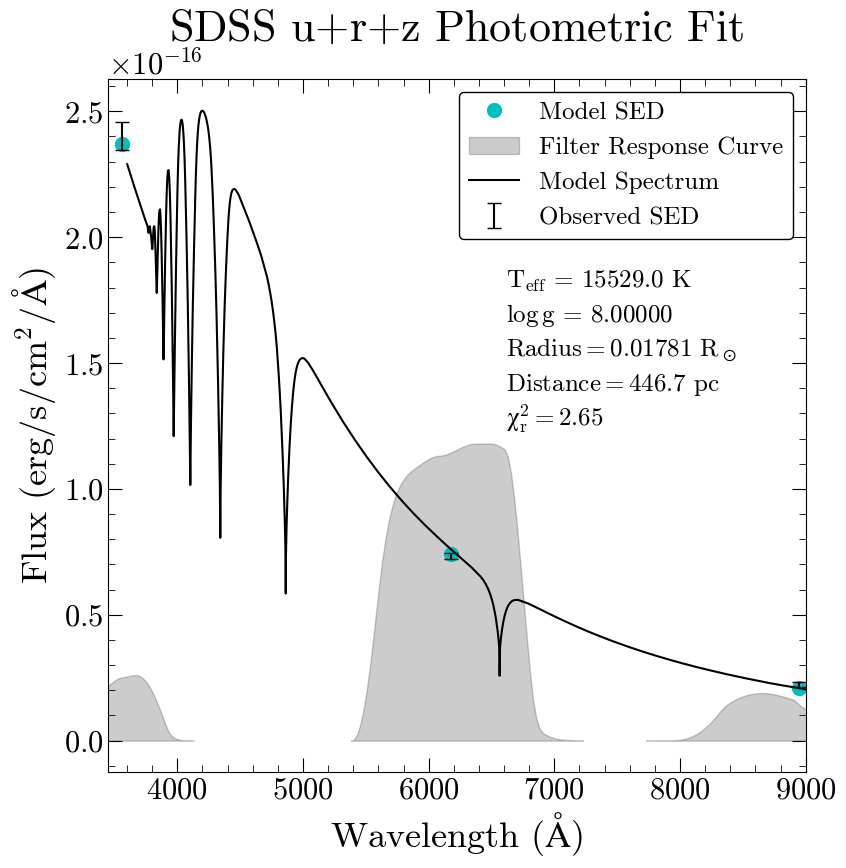

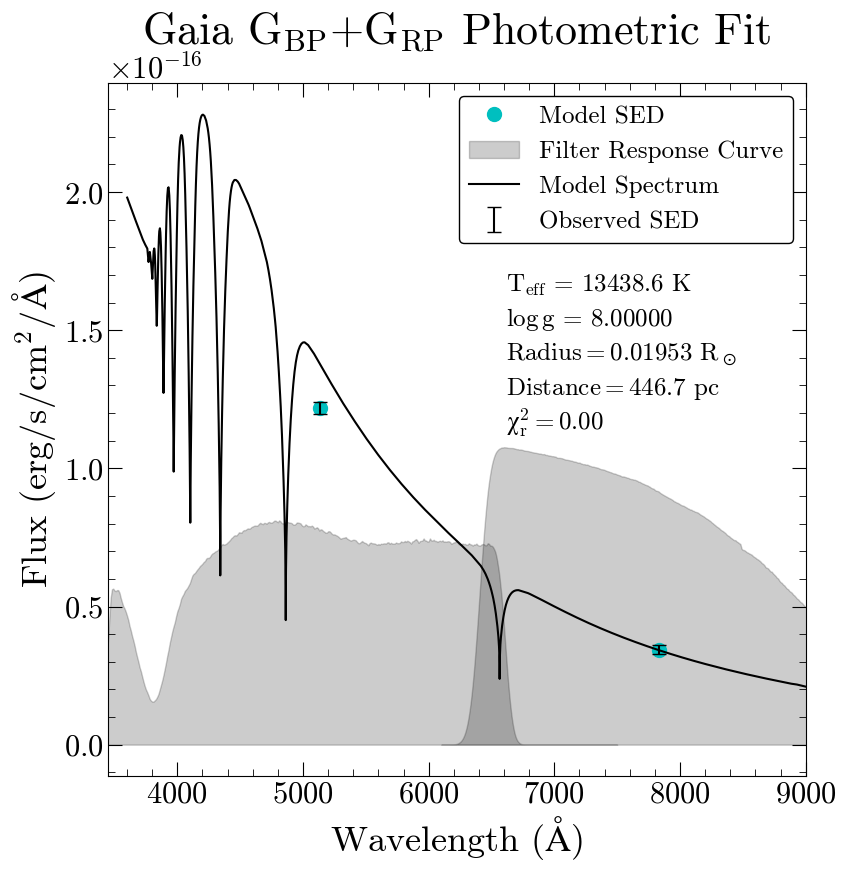

  0%|                                                     | 0/1 [00:00<?, ?it/s]

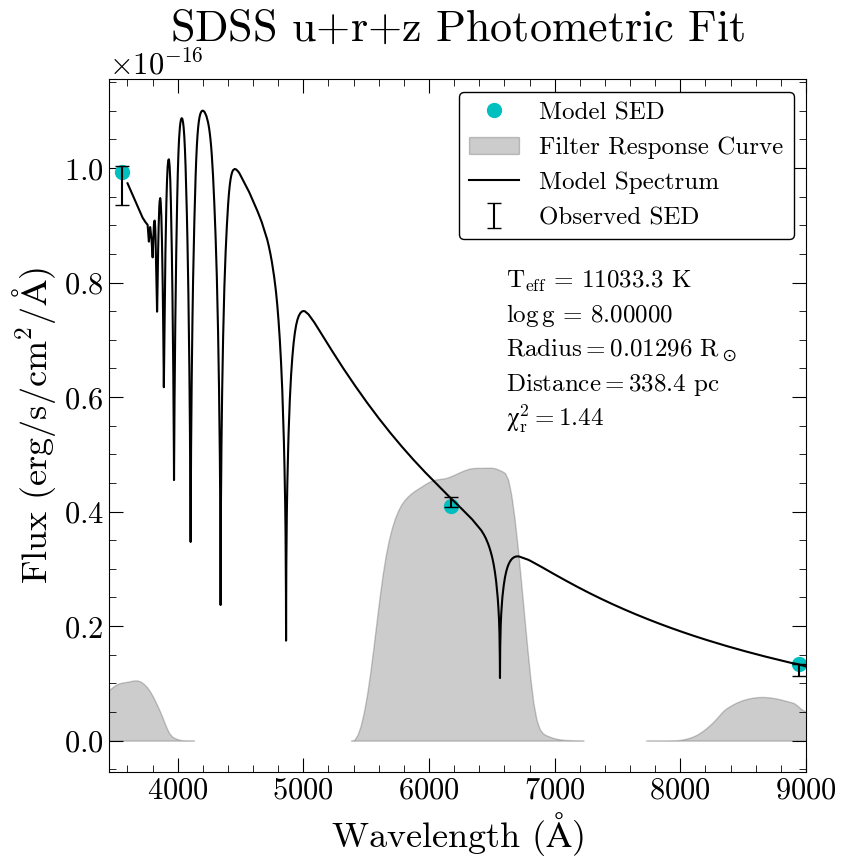

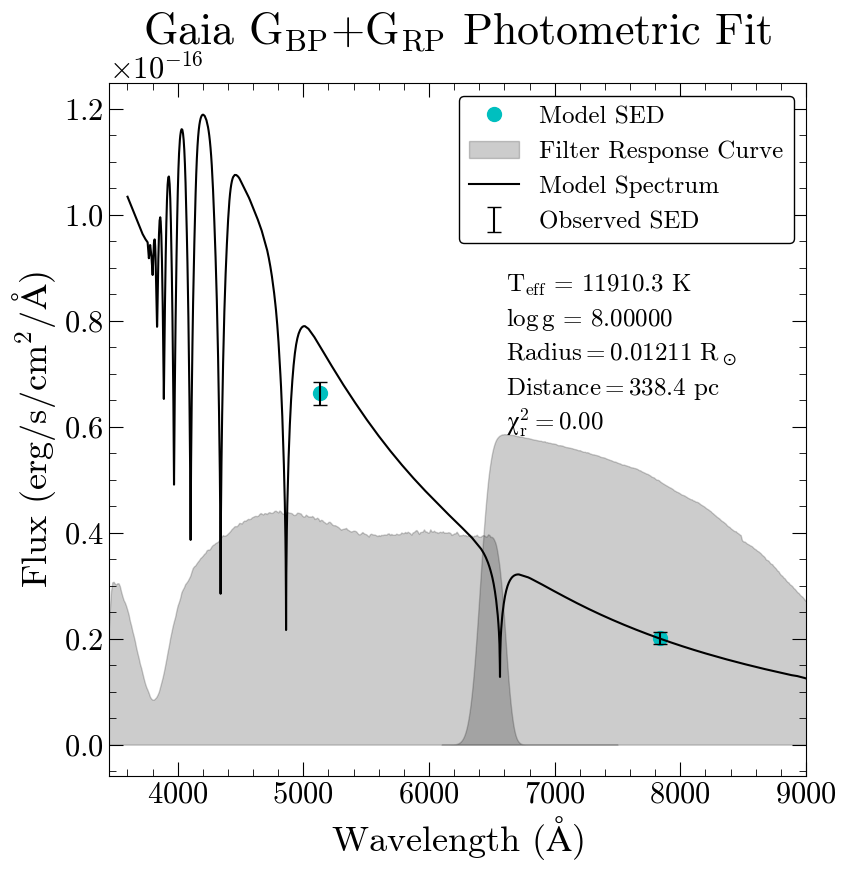

  0%|                                                     | 0/1 [00:00<?, ?it/s]

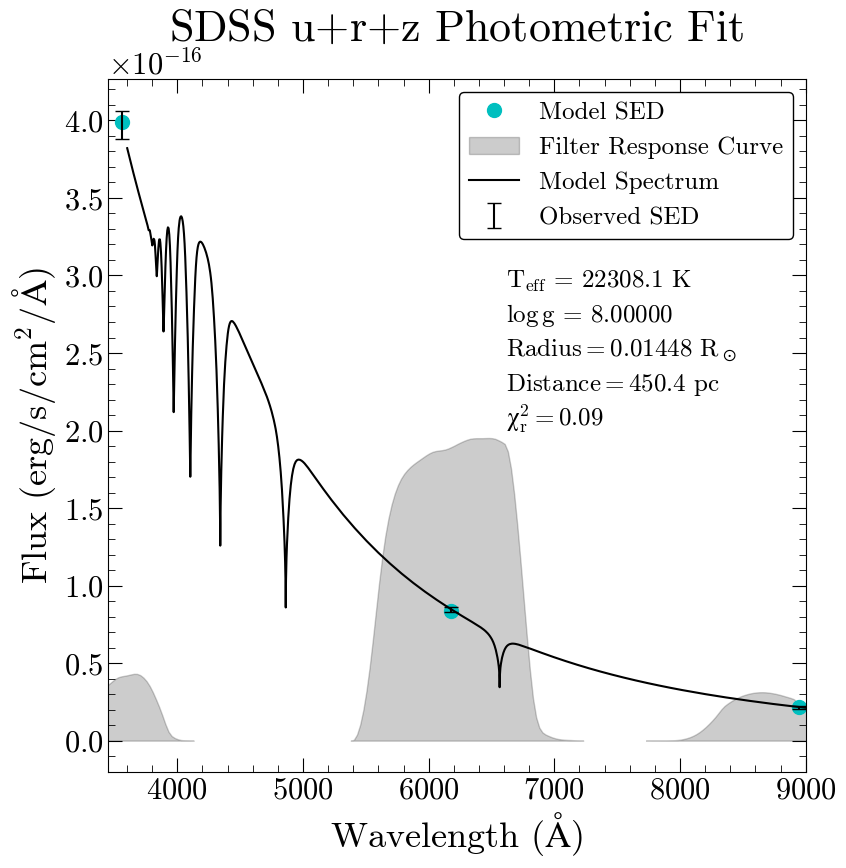

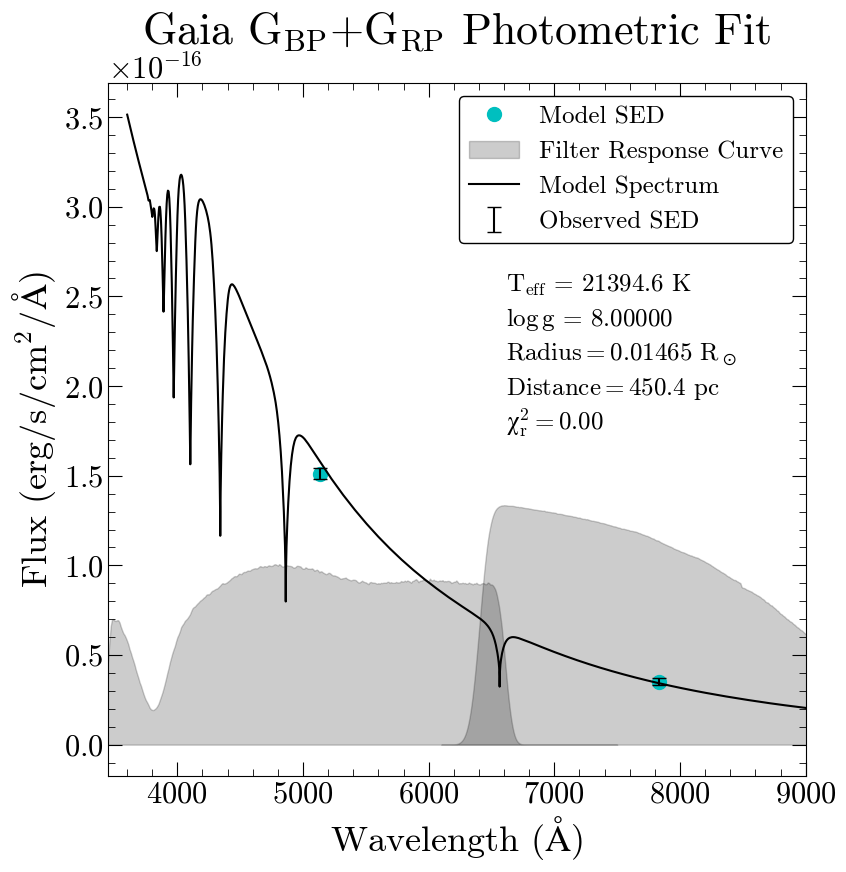

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.46s/it]


In [71]:
num_id5=1 #which table
obj_id5=671200102992315264 #which object
mjd5=59302 #which observation
wd_table5=SDSSV_dict['set_'+str(num_id5)].query('gaia_dr3_source_id==@obj_id5 and mjd==@mjd5')
#reset the indices
indices=np.arange(0,len(wd_table5))
wd_table5.set_index(indices,inplace=True)
snr5=wd_table5['snr'][0]

num_id10=1
obj_id10=683776390006118656
mjd10=59202
wd_table10=SDSSV_dict['set_'+str(num_id10)].query('gaia_dr3_source_id==@obj_id10 and mjd==@mjd10')
#reset the indices
indices=np.arange(0,len(wd_table10))
wd_table10.set_index(indices,inplace=True)
snr10=wd_table10['snr'][0]

num_id20=2
obj_id20=877876093938694912
mjd20=59167
wd_table20=SDSSV_dict['set_'+str(num_id20)].query('gaia_dr3_source_id==@obj_id20 and mjd==@mjd20')
#reset the indices
indices=np.arange(0,len(wd_table20))
wd_table20.set_index(indices,inplace=True)
snr20=wd_table20['snr'][0]

fig5_sdss,fig5_gaia=fit_phot(wd_table5,'med',plot=True,savefig=True)
fig10_sdss,fig10_gaia=fit_phot(wd_table10,'med',plot=True,savefig=True)
fig20_sdss,fig20_gaia=fit_phot(wd_table20,'med',plot=True,savefig=True)

#save the figures
fig10_gaia.savefig('Phot_fit_10_gaia.png', dpi=500)
fig20_sdss.savefig('Phot_fit_20_sdss.png', dpi=500)

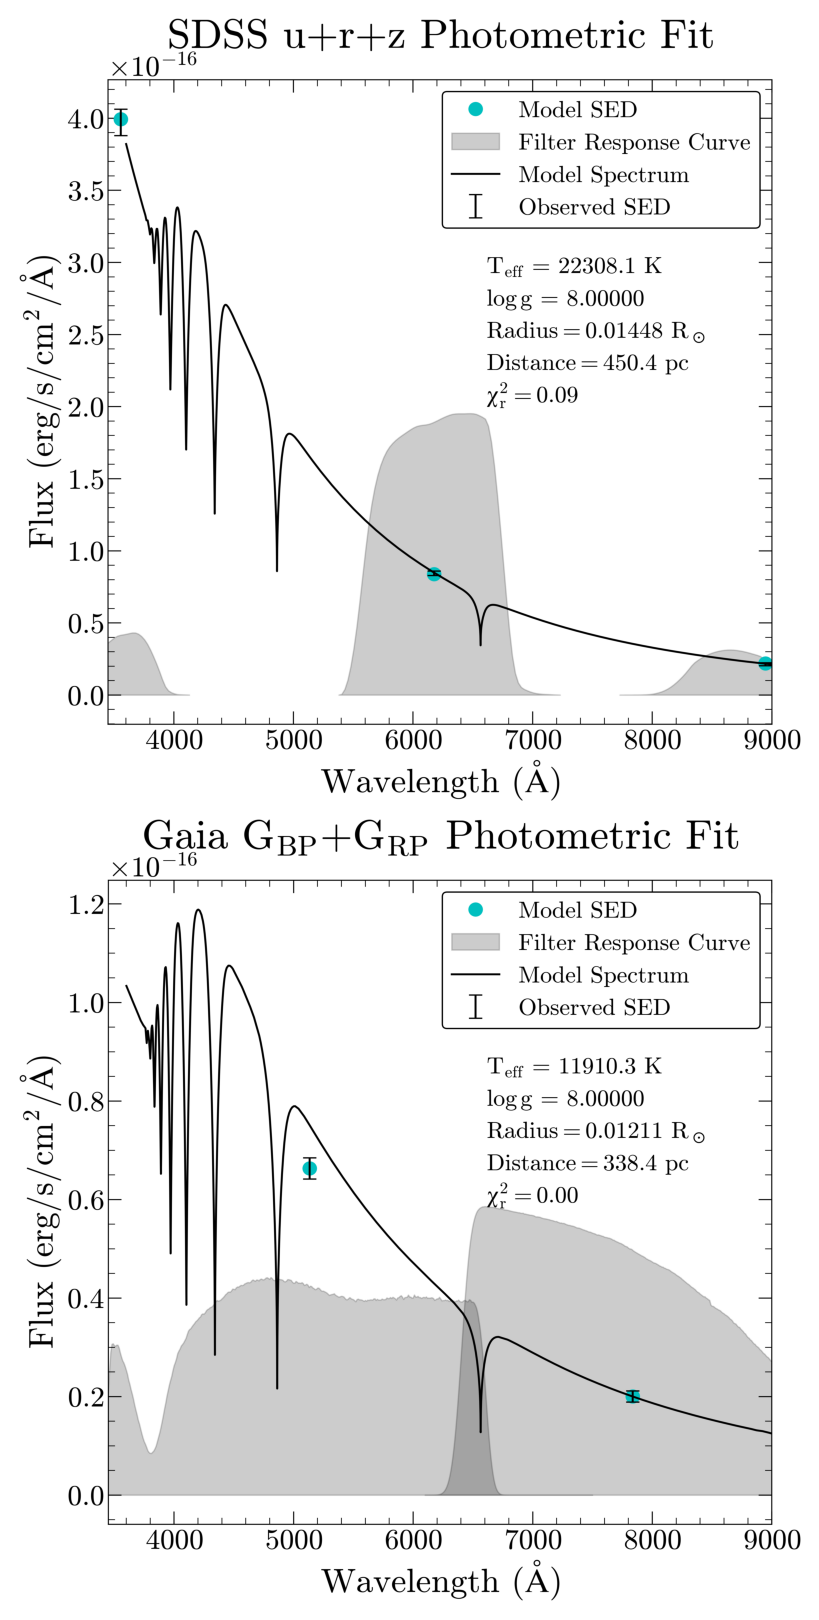

In [72]:
#combine the fit plots
fig=plt.figure(figsize=(8,16))
plt.style.use('stefan.mplstyle')

# Load the saved images and add to the plot
image20 = plt.imread('Phot_fit_20_sdss.png')
fig.add_subplot(2,1,1)
plt.imshow(image20)
plt.axis('off')

image10 = plt.imread('Phot_fit_10_gaia.png')
fig.add_subplot(2,1,2)
plt.imshow(image10)
plt.axis('off')

fig.tight_layout(pad=0)
plt.savefig('Phot_fit.pdf', dpi=300)#,pad_inches=0.3)